In [ ]:
!pip install ripser

# BVP -> TPV

In [2]:
import os
import glob
import numpy as np
import pandas as pd

from ripser import ripser
from scipy.signal import butter, filtfilt, find_peaks, welch
from scipy.stats import iqr, skew, kurtosis, entropy
from scipy.spatial.distance import pdist
from scipy.interpolate import interp1d

# =============================================================================
# CONFIG
# =============================================================================
ROOT_DIR = r"/content/drive/MyDrive/Colab Notebooks/datasets/EmpaticaE4Stress"
OUTPUT_DIR = r"/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/EmpaticaE4Stress/BVP_TPV"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EXCLUDE_SUBJECTS = {"subject_23"}

FS_BVP = 64
FS_ACC = 32

WINDOW_SEC = 60
STEP_SEC = 60

LABEL_NORMAL = 0
LABEL_STRESS = 1

STATUS_NAME_MAP = {
    LABEL_NORMAL: "normal",
    LABEL_STRESS: "stress"
}

# BVP filter
LOWCUT = 0.5
HIGHCUT = 8.0
FILTER_ORDER = 4

# ---- Hard reject thresholds ----
FLATLINE_EPS = 1e-3
FLATLINE_MIN_SEC = 1.0
CLIPPING_RATIO_MAX = 0.10
MIN_PEAKS_PER_MIN = 30

# ---- Relaxed QC thresholds ----
VBR_MIN = 0.70
TC_MIN = 0.75
IBI_PASS_MIN = 0.80
MOTION_PERCENTILE = 80

# ---- Peak / beat extraction ----
MIN_HR_BPM = 40
MAX_HR_BPM = 180
MIN_PEAK_DISTANCE_SEC = 60.0 / MAX_HR_BPM
IBI_MIN_SEC = 0.30
IBI_MAX_SEC = 1.50

BEAT_BEFORE_SEC = 0.25
BEAT_AFTER_SEC = 0.45
BEAT_RESAMPLED_LEN = 100

# ---- Motion artifact thresholds ----
ALLOW_MISSING = False
ACC_DIFF_THRESH = 0.05
PSD_CORR_THRESH = 0.90
PSD_FMIN = 0.5
PSD_FMAX = 8.0

# selected TPV features only (WESAD BVP code와 동일)
SELECTED_TPV_INDICES = [22, 9, 4, 2, 0, 28, 8, 19, 14, 26, 11]

TPV_FEATURE_NAMES = [
    "birth_mean", "birth_std", "death_mean", "death_std",
    "lifetime_mean", "lifetime_std", "lifetime_max", "lifetime_min",
    "lifetime_median", "lifetime_iqr", "lifetime_skew", "lifetime_kurtosis",
    "birth_max", "birth_min", "birth_median", "birth_skew", "birth_kurtosis",
    "death_max", "death_min", "death_median", "death_skew", "death_kurtosis",
    "num_lifetimes", "top1_lifetime", "top2_lifetime", "lifetime_max_div_min",
    "ph_entropy", "betti_entropy", "avg_persistence_distance", "gini_index",
    "lifetime_variance", "persistent_image_energy",
]
N_FEATURES = len(TPV_FEATURE_NAMES)


# =============================================================================
# DATA LOADERS
# =============================================================================
def load_1col_signal_csv(file_path, fs):
    raw = pd.read_csv(file_path, header=None)
    data = pd.to_numeric(raw.iloc[:, 0], errors="coerce").dropna().to_numpy(dtype=np.float32)
    timestamps = np.arange(len(data), dtype=np.float32) / fs
    return {
        "data": data,
        "timestamps": timestamps,
        "fs": fs,
        "n_samples": len(data),
        "duration_sec": len(data) / fs
    }


def load_acc_csv(file_path, fs=FS_ACC):
    raw = pd.read_csv(file_path, header=None)

    # 일반적인 3축 구조 가정
    if raw.shape[1] >= 3:
        acc = raw.iloc[:, :3].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)
    else:
        # 혹시 한 컬럼에 "x,y,z" 문자열로 들어있을 때 대비
        tmp = raw.iloc[:, 0].astype(str).str.split(",", expand=True)
        if tmp.shape[1] < 3:
            raise ValueError(f"ACC format error in {file_path}")
        acc = tmp.iloc[:, :3].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)

    # row-wise NaN drop
    mask = np.all(np.isfinite(acc), axis=1)
    acc = acc[mask]

    timestamps = np.arange(len(acc), dtype=np.float32) / fs
    return {
        "data": acc,
        "timestamps": timestamps,
        "fs": fs,
        "n_samples": len(acc),
        "duration_sec": len(acc) / fs
    }


# =============================================================================
# PROTOCOL (Task4 auto-estimation)
# =============================================================================
def build_protocol_intervals_from_total_duration(total_duration_sec: float) -> pd.DataFrame:
    fixed_sum_excluding_task4 = (
        180 + 600 + 120 + 300 + 120 + 180 + 120 + 120 + 60 + 120
    )  # = 1920 sec

    task4_duration = float(total_duration_sec) - fixed_sum_excluding_task4
    if task4_duration <= 0:
        raise ValueError(
            f"Task4 duration <= 0. total_duration={total_duration_sec:.3f}, "
            f"fixed_sum={fixed_sum_excluding_task4}"
        )

    phases = [
        ("Rest1", 180.0, 0),
        ("Task1", 600.0, 1),
        ("Rest2", 120.0, 0),
        ("Task2", 300.0, 1),
        ("Rest3", 120.0, 0),
        ("Task3", 180.0, 1),
        ("Rest4", 120.0, 0),
        ("Task4", task4_duration, 1),
        ("Rest5", 120.0, 0),
        ("Task5", 60.0, 1),
        ("Rest6", 120.0, 0),
    ]

    rows = []
    t = 0.0
    for idx, (phase_name, dur, label) in enumerate(phases):
        rows.append({
            "interval_idx": idx,
            "phase": phase_name,
            "start": t,
            "end": t + dur,
            "duration_sec": dur,
            "label": label
        })
        t += dur

    return pd.DataFrame(rows)


def build_window_table_from_intervals(intervals_df, window_sec=60, step_sec=60):
    rows = []
    for _, r in intervals_df.iterrows():
        start = float(r["start"])
        end = float(r["end"])
        phase = r["phase"]
        label = int(r["label"])

        t = start
        while t + window_sec <= end:
            rows.append({
                "phase": phase,
                "label": label,
                "window_start": t,
                "window_end": t + window_sec,
                "major_ratio": 1.0
            })
            t += step_sec

    return pd.DataFrame(rows)


# =============================================================================
# Basic utils
# =============================================================================
def fill_nan_with_median(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32).reshape(-1).copy()
    if np.isnan(x).any():
        med = np.nanmedian(x)
        if np.isnan(med):
            med = 0.0
        x = np.nan_to_num(x, nan=med, posinf=med, neginf=med)
    return x


def fill_nan_acc_with_median(acc_xyz: np.ndarray) -> np.ndarray:
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32).copy()
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3:
        return acc_xyz
    for c in range(3):
        ch = acc_xyz[:, c]
        med = np.nanmedian(ch)
        if np.isnan(med):
            med = 0.0
        ch = np.nan_to_num(ch, nan=med, posinf=med, neginf=med)
        acc_xyz[:, c] = ch
    return acc_xyz


def bandpass_filter(sig, fs=64, low=0.5, high=8.0, order=4):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    nyq = 0.5 * fs
    low_n = low / nyq
    high_n = high / nyq

    if not (0 < low_n < high_n < 1):
        raise ValueError(f"Invalid bandpass range: low={low}, high={high}, fs={fs}")

    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, sig).astype(np.float32)


def zscore_1d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    mu = float(np.mean(x))
    sd = float(np.std(x))
    if sd < 1e-8:
        return np.zeros_like(x, dtype=np.float32)
    return ((x - mu) / (sd + 1e-8)).astype(np.float32)


def safe_skew(x: np.ndarray) -> float:
    if len(x) > 2 and np.std(x) > 1e-12:
        v = skew(x)
        return float(v) if np.isfinite(v) else 0.0
    return 0.0


def safe_kurtosis(x: np.ndarray) -> float:
    if len(x) > 3 and np.std(x) > 1e-12:
        v = kurtosis(x)
        return float(v) if np.isfinite(v) else 0.0
    return 0.0


def clamp01(x):
    return float(np.clip(x, 0.0, 1.0))


def compute_missing_ratio(x: np.ndarray) -> float:
    x = np.asarray(x)
    return float(np.mean(~np.isfinite(x)))


# =============================================================================
# TPV extraction
# =============================================================================
def extract_tpv_features(sig_1d: np.ndarray) -> np.ndarray:
    sig = np.asarray(sig_1d, dtype=np.float32).reshape(-1)

    if len(sig) < 3:
        return np.zeros(N_FEATURES, dtype=np.float32)

    s = float(np.std(sig))
    if s < 1e-8:
        return np.zeros(N_FEATURES, dtype=np.float32)

    sig = (sig - float(np.mean(sig))) / (s + 1e-8)

    X = np.stack([sig[:-1], sig[1:]], axis=1)
    dgms = ripser(X, maxdim=1)["dgms"]
    H1 = dgms[1]

    if H1.size == 0:
        return np.zeros(N_FEATURES, dtype=np.float32)

    births = H1[:, 0]
    deaths = H1[:, 1]
    lifetimes = deaths - births

    mask = np.isfinite(births) & np.isfinite(deaths) & np.isfinite(lifetimes)
    births = births[mask]
    deaths = deaths[mask]
    lifetimes = lifetimes[mask]

    if len(lifetimes) == 0:
        return np.zeros(N_FEATURES, dtype=np.float32)

    lifetimes_sorted = np.sort(lifetimes)
    lifetime_sum = float(np.sum(lifetimes))
    lifetime_ratio = lifetimes / (lifetime_sum + 1e-8)
    ph_entropy = float(-np.sum(lifetime_ratio * np.log(lifetime_ratio + 1e-10)))

    bmin = float(np.min(births))
    bmax = float(np.max(births))
    if bmax - bmin < 1e-8:
        betti_entropy = 0.0
    else:
        hist, _ = np.histogram(births, bins=10, range=(bmin, bmax), density=True)
        betti_entropy = float(entropy(hist + 1e-10))

    avg_persistence_distance = (
        float(np.mean(pdist(lifetimes[:, None]))) if len(lifetimes) > 1 else 0.0
    )

    if np.sum(lifetimes_sorted) > 0 and len(lifetimes_sorted) > 1:
        n = len(lifetimes_sorted)
        gini = (
            2 * np.sum(np.arange(1, n + 1) * lifetimes_sorted)
        ) / (n * np.sum(lifetimes_sorted)) - (n + 1) / n
        gini_index = float(gini)
    else:
        gini_index = 0.0

    lifetime_variance = float(np.var(lifetimes))
    persistent_image_energy = float(np.sum(lifetimes ** 2))

    feats = [
        float(np.mean(births)), float(np.std(births)),
        float(np.mean(deaths)), float(np.std(deaths)),
        float(np.mean(lifetimes)), float(np.std(lifetimes)),
        float(np.max(lifetimes)), float(np.min(lifetimes)),
        float(np.median(lifetimes)), float(iqr(lifetimes)),
        safe_skew(lifetimes), safe_kurtosis(lifetimes),
        float(np.max(births)), float(np.min(births)),
        float(np.median(births)), safe_skew(births), safe_kurtosis(births),
        float(np.max(deaths)), float(np.min(deaths)),
        float(np.median(deaths)), safe_skew(deaths), safe_kurtosis(deaths),
        float(len(lifetimes)),
        float(lifetimes_sorted[-1]),
        float(lifetimes_sorted[-2]) if len(lifetimes_sorted) > 1 else 0.0,
        float(np.max(lifetimes) / (np.min(lifetimes) + 1e-8)),
        ph_entropy,
        betti_entropy,
        avg_persistence_distance,
        gini_index,
        lifetime_variance,
        persistent_image_energy,
    ]
    return np.asarray(feats, dtype=np.float32)


# =============================================================================
# QC metric helpers
# =============================================================================
def is_flatline(sig: np.ndarray, fs: int, eps: float = FLATLINE_EPS, min_sec: float = FLATLINE_MIN_SEC) -> bool:
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    run_len = int(round(fs * min_sec))
    if len(sig) < run_len:
        return False
    ds = np.abs(np.diff(sig))
    low_change = ds < eps
    cnt = 0
    for v in low_change:
        if v:
            cnt += 1
            if cnt >= run_len - 1:
                return True
        else:
            cnt = 0
    return False


def clipping_ratio(sig: np.ndarray) -> float:
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    if len(sig) == 0:
        return 1.0
    lo = np.percentile(sig, 1)
    hi = np.percentile(sig, 99)
    if hi - lo < 1e-8:
        return 1.0
    near_lo = sig <= (lo + 0.01 * (hi - lo))
    near_hi = sig >= (hi - 0.01 * (hi - lo))
    return float(np.mean(near_lo | near_hi))


def detect_ppg_peaks(sig: np.ndarray, fs: int):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    distance = max(1, int(round(MIN_PEAK_DISTANCE_SEC * fs)))
    prom = max(0.10, 0.20 * float(np.std(sig)))
    peaks, props = find_peaks(sig, distance=distance, prominence=prom)
    return peaks, props


def compute_motion_score(acc_xyz: np.ndarray) -> float:
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32)
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3 or len(acc_xyz) < 2:
        return 1.0
    mag = np.sqrt(np.sum(acc_xyz ** 2, axis=1))
    dmag = np.abs(np.diff(mag))
    score = np.median(dmag) + 0.5 * np.std(dmag)
    return float(score)


def compute_acc_diff_metrics(acc_xyz: np.ndarray):
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32)
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3 or len(acc_xyz) < 2:
        return {
            "acc_diff_mean": np.nan,
            "acc_diff_exceed_ratio": np.nan,
            "acc_diff_flag": 1
        }

    mag = np.sqrt(np.sum(acc_xyz ** 2, axis=1))
    dmag = np.abs(np.diff(mag))

    acc_diff_mean = float(np.mean(dmag)) if len(dmag) > 0 else 0.0
    acc_diff_exceed_ratio = float(np.mean(dmag > ACC_DIFF_THRESH)) if len(dmag) > 0 else 0.0
    acc_diff_flag = int(acc_diff_mean > ACC_DIFF_THRESH)

    return {
        "acc_diff_mean": acc_diff_mean,
        "acc_diff_exceed_ratio": acc_diff_exceed_ratio,
        "acc_diff_flag": acc_diff_flag
    }


def _safe_psd_1d(x: np.ndarray, fs: int, fmin: float, fmax: float):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) < 8:
        return None, None

    x = x[np.isfinite(x)]
    if len(x) < 8:
        return None, None

    if np.std(x) < 1e-8:
        return None, None

    nperseg = min(256, len(x))
    f, pxx = welch(x, fs=fs, nperseg=nperseg)

    mask = (f >= fmin) & (f <= min(fmax, fs / 2 - 1e-6))
    if np.sum(mask) < 4:
        return None, None

    return f[mask], pxx[mask]


def _corr_on_common_freq(f_ref, p_ref, f_other, p_other):
    if f_ref is None or f_other is None:
        return np.nan

    p_other_interp = np.interp(f_ref, f_other, p_other)
    a = np.log1p(p_ref)
    b = np.log1p(p_other_interp)

    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return np.nan

    r = np.corrcoef(a, b)[0, 1]
    return float(r) if np.isfinite(r) else np.nan


def compute_bvp_acc_psd_corr(seg_bvp_bp: np.ndarray, seg_acc_xyz: np.ndarray,
                             fs_bvp: int, fs_acc: int,
                             fmin: float = PSD_FMIN, fmax: float = PSD_FMAX):
    out = {
        "psd_corr_x": np.nan,
        "psd_corr_y": np.nan,
        "psd_corr_z": np.nan,
        "psd_corr_mag": np.nan,
        "psd_corr_max": np.nan,
        "psd_corr_flag": 1
    }

    seg_bvp_bp = np.asarray(seg_bvp_bp, dtype=np.float32).reshape(-1)
    acc_xyz = np.asarray(seg_acc_xyz, dtype=np.float32)

    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3:
        return out

    f_bvp, p_bvp = _safe_psd_1d(seg_bvp_bp, fs_bvp, fmin, fmax)
    if f_bvp is None:
        return out

    acc_mag = np.sqrt(np.sum(acc_xyz ** 2, axis=1))

    corr_list = []
    names_and_signals = [
        ("x", acc_xyz[:, 0]),
        ("y", acc_xyz[:, 1]),
        ("z", acc_xyz[:, 2]),
        ("mag", acc_mag),
    ]

    for name, sig in names_and_signals:
        f_acc, p_acc = _safe_psd_1d(sig, fs_acc, fmin, fmax)
        r = _corr_on_common_freq(f_bvp, p_bvp, f_acc, p_acc)
        out[f"psd_corr_{name}"] = r
        if np.isfinite(r):
            corr_list.append(r)

    if len(corr_list) == 0:
        return out

    psd_corr_max = float(np.max(corr_list))
    out["psd_corr_max"] = psd_corr_max
    out["psd_corr_flag"] = int(psd_corr_max >= PSD_CORR_THRESH)

    return out


def extract_beats(sig: np.ndarray, peaks: np.ndarray, fs: int):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    beats = []
    before = int(round(BEAT_BEFORE_SEC * fs))
    after = int(round(BEAT_AFTER_SEC * fs))
    target_x = np.linspace(0, 1, BEAT_RESAMPLED_LEN)

    for p in peaks:
        s = p - before
        e = p + after
        if s < 0 or e > len(sig):
            continue
        beat = sig[s:e].copy()
        if len(beat) < 5:
            continue
        src_x = np.linspace(0, 1, len(beat))
        f = interp1d(src_x, beat, kind="linear")
        beat_rs = f(target_x).astype(np.float32)
        beats.append(beat_rs)

    if len(beats) == 0:
        return np.empty((0, BEAT_RESAMPLED_LEN), dtype=np.float32)
    return np.stack(beats, axis=0)


def median_template_corr(beats: np.ndarray) -> float:
    if beats.ndim != 2 or len(beats) < 2:
        return 0.0
    template = np.median(beats, axis=0)
    tc_list = []
    for b in beats:
        sb = np.std(b)
        st = np.std(template)
        if sb < 1e-8 or st < 1e-8:
            tc_list.append(0.0)
        else:
            r = np.corrcoef(b, template)[0, 1]
            tc_list.append(float(r) if np.isfinite(r) else 0.0)
    return float(np.median(tc_list)) if len(tc_list) > 0 else 0.0


def compute_ibi_metrics(peaks: np.ndarray, fs: int):
    peaks = np.asarray(peaks, dtype=np.int64)
    if len(peaks) < 3:
        return {
            "n_peaks": int(len(peaks)),
            "ibi_pass_ratio": 0.0,
            "valid_beat_ratio": 0.0,
            "ibi_plausibility": 0.0,
            "ibi_mean_sec": np.nan,
        }

    ibi = np.diff(peaks) / float(fs)
    plausible = (ibi >= IBI_MIN_SEC) & (ibi <= IBI_MAX_SEC)
    ibi_pass_ratio = float(np.mean(plausible)) if len(ibi) > 0 else 0.0

    if len(ibi) >= 3:
        med_ibi = np.median(ibi)
        valid = plausible & (np.abs(ibi - med_ibi) <= 0.30 * (med_ibi + 1e-8))
        vbr = float(np.mean(valid))
    else:
        vbr = ibi_pass_ratio

    return {
        "n_peaks": int(len(peaks)),
        "ibi_pass_ratio": ibi_pass_ratio,
        "valid_beat_ratio": vbr,
        "ibi_plausibility": ibi_pass_ratio,
        "ibi_mean_sec": float(np.mean(ibi)) if len(ibi) > 0 else np.nan,
    }


def notch_foot_peak_detectability_score(beats: np.ndarray) -> float:
    if beats.ndim != 2 or len(beats) == 0:
        return 0.0

    scores = []
    for b in beats:
        foot = np.min(b[:max(5, len(b)//4)])
        peak = np.max(b)
        amp = peak - foot
        dyn = np.max(b) - np.min(b) + 1e-8
        s = amp / dyn
        scores.append(clamp01(s))

    return float(np.median(scores)) if len(scores) > 0 else 0.0


def compute_sqi_scores(vbr, tc, ibi_plausibility, motion_score, morph_score):
    motion_penalty = clamp01(motion_score)

    sqi_stress_basic = (
        0.40 * clamp01(vbr)
        + 0.30 * clamp01(tc)
        + 0.20 * clamp01(ibi_plausibility)
        - 0.10 * motion_penalty
    )

    sqi_stress_morph = (
        0.30 * clamp01(vbr)
        + 0.25 * clamp01(tc)
        + 0.20 * clamp01(ibi_plausibility)
        + 0.25 * clamp01(morph_score)
        - motion_penalty
    )

    return float(sqi_stress_basic), float(sqi_stress_morph), motion_penalty


def evaluate_window_quality(seg_bvp_raw: np.ndarray, seg_acc_xyz: np.ndarray, fs_bvp: int, fs_acc: int):
    out = {}

    out["bvp_missing_ratio"] = compute_missing_ratio(seg_bvp_raw)
    out["acc_missing_ratio"] = compute_missing_ratio(seg_acc_xyz)
    out["missing_flag"] = int(
        (out["bvp_missing_ratio"] > 0.0) or (out["acc_missing_ratio"] > 0.0)
    ) if not ALLOW_MISSING else 0

    seg_bvp = fill_nan_with_median(seg_bvp_raw)
    seg_acc_xyz = fill_nan_acc_with_median(seg_acc_xyz)

    seg_bvp_bp = bandpass_filter(seg_bvp, fs=fs_bvp, low=LOWCUT, high=HIGHCUT, order=FILTER_ORDER)
    seg_bvp_z = zscore_1d(seg_bvp_bp)

    out["flatline_flag"] = int(is_flatline(seg_bvp_bp, fs=fs_bvp))
    out["clipping_ratio"] = clipping_ratio(seg_bvp_bp)
    out["clipping_flag"] = int(out["clipping_ratio"] > CLIPPING_RATIO_MAX)

    peaks, props = detect_ppg_peaks(seg_bvp_z, fs=fs_bvp)
    out["n_peaks"] = int(len(peaks))
    out["peak_sparse_flag"] = int(len(peaks) < MIN_PEAKS_PER_MIN)

    ibi_info = compute_ibi_metrics(peaks, fs_bvp)
    out.update(ibi_info)

    beats = extract_beats(seg_bvp_z, peaks, fs_bvp)
    tc = median_template_corr(beats)
    morph_score = notch_foot_peak_detectability_score(beats)
    motion_score_raw = compute_motion_score(seg_acc_xyz)

    out["median_template_corr"] = float(tc)
    out["notch_foot_peak_detectability"] = float(morph_score)
    out["motion_score_raw"] = float(motion_score_raw)

    sqi_basic, sqi_morph, motion_penalty = compute_sqi_scores(
        vbr=out["valid_beat_ratio"],
        tc=tc,
        ibi_plausibility=out["ibi_plausibility"],
        motion_score=motion_score_raw,
        morph_score=morph_score
    )

    out["motion_score"] = float(motion_penalty)
    out["SQI_stress_basic"] = float(sqi_basic)
    out["SQI_stress_morph"] = float(sqi_morph)

    acc_diff_info = compute_acc_diff_metrics(seg_acc_xyz)
    out.update(acc_diff_info)

    psd_corr_info = compute_bvp_acc_psd_corr(
        seg_bvp_bp=seg_bvp_bp,
        seg_acc_xyz=seg_acc_xyz,
        fs_bvp=fs_bvp,
        fs_acc=fs_acc,
        fmin=PSD_FMIN,
        fmax=PSD_FMAX
    )
    out.update(psd_corr_info)

    hard_reject = (
        (out["missing_flag"] == 1) or
        (out["flatline_flag"] == 1) or
        (out["clipping_flag"] == 1) or
        (out["peak_sparse_flag"] == 1) or
        (out["acc_diff_flag"] == 1) or
        (out["psd_corr_flag"] == 1)
    )
    out["hard_reject"] = int(hard_reject)

    return seg_bvp_z, out


# =============================================================================
# Build table for one subject
# =============================================================================
def build_subject_windows_table(subject_dir: str, subject_name: str) -> pd.DataFrame:
    bvp_path = os.path.join(subject_dir, "BVP.csv")
    acc_path = os.path.join(subject_dir, "ACC.csv")

    if not (os.path.exists(bvp_path) and os.path.exists(acc_path)):
        return pd.DataFrame()

    bvp_pack = load_1col_signal_csv(bvp_path, FS_BVP)
    acc_pack = load_acc_csv(acc_path, FS_ACC)

    bvp = bvp_pack["data"]
    acc = acc_pack["data"]

    total_duration_sec = min(bvp_pack["duration_sec"], acc_pack["duration_sec"])

    intervals_df = build_protocol_intervals_from_total_duration(total_duration_sec)
    window_df = build_window_table_from_intervals(intervals_df, WINDOW_SEC, STEP_SEC)

    Wb = int(WINDOW_SEC * FS_BVP)
    Wa = int(WINDOW_SEC * FS_ACC)

    rows = []
    window_counter = 0

    for _, w in window_df.iterrows():
        t0 = float(w["window_start"])
        t1 = float(w["window_end"])

        start_b = int(round(t0 * FS_BVP))
        end_b = start_b + Wb
        start_a = int(round(t0 * FS_ACC))
        end_a = start_a + Wa

        if end_b > len(bvp) or end_a > len(acc):
            continue

        seg_bvp_raw = bvp[start_b:end_b]
        seg_acc_xyz = acc[start_a:end_a]

        if len(seg_bvp_raw) != Wb or len(seg_acc_xyz) != Wa:
            continue

        seg_bvp_for_tpv, qc_info = evaluate_window_quality(seg_bvp_raw, seg_acc_xyz, FS_BVP, FS_ACC)
        tpv_full = extract_tpv_features(seg_bvp_for_tpv)

        window_counter += 1

        row = {
            "subject": subject_name,
            "window": f"window{window_counter}",
            "window_index": window_counter,
            "status": int(w["label"]),
            "status_name": STATUS_NAME_MAP[int(w["label"])],
            "label_major": int(w["label"]),
            "phase": w["phase"],
            "t_start_sec": float(t0),
            "t_end_sec": float(t1),
            "major_ratio": float(w["major_ratio"]),
            "subject_total_duration_sec": total_duration_sec,
            "task4_duration_sec": float(intervals_df.loc[intervals_df["phase"] == "Task4", "duration_sec"].iloc[0]),
        }

        for k, v in qc_info.items():
            row[k] = v

        for idx in SELECTED_TPV_INDICES:
            row[f"TPV{idx}"] = float(tpv_full[idx])

        rows.append(row)

    return pd.DataFrame(rows)


# =============================================================================
# Build all subjects
# =============================================================================
def build_all_subjects_windows_table(root_dir: str) -> pd.DataFrame:
    subject_dirs = sorted([d for d in glob.glob(os.path.join(root_dir, "subject_*")) if os.path.isdir(d)])
    all_dfs = []

    print(f"[INFO] Found {len(subject_dirs)} subject folders")

    for subject_dir in subject_dirs:
        subject_name = os.path.basename(subject_dir)

        if subject_name in EXCLUDE_SUBJECTS:
            print(f"[INFO] Skip excluded subject: {subject_name}")
            continue

        print(f"\n[INFO] Processing {subject_name} ...")
        try:
            df_sub = build_subject_windows_table(subject_dir, subject_name)
            print(f"[INFO] {subject_name}: extracted {len(df_sub)} target windows")
            if len(df_sub) > 0:
                all_dfs.append(df_sub)
        except Exception as e:
            print(f"[WARN] Failed on {subject_name}: {e}")

    if len(all_dfs) == 0:
        return pd.DataFrame()

    return pd.concat(all_dfs, axis=0, ignore_index=True)


# =============================================================================
# Personalized QC pass/fail
# =============================================================================
def apply_relaxed_personalized_qc(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    motion_thr_map = (
        df.groupby("subject")["motion_score"]
        .quantile(MOTION_PERCENTILE / 100.0)
        .to_dict()
    )

    df["motion_threshold_subject_p80"] = df["subject"].map(motion_thr_map)

    df["qc_relaxed_pass"] = (
        (df["hard_reject"] == 0) &
        (df["valid_beat_ratio"] >= VBR_MIN) &
        (df["median_template_corr"] >= TC_MIN) &
        (df["ibi_pass_ratio"] >= IBI_PASS_MIN) &
        (df["motion_score"] <= df["motion_threshold_subject_p80"])
    ).astype(int)

    return df


# =============================================================================
# Main
# =============================================================================
if __name__ == "__main__":
    df_all = build_all_subjects_windows_table(ROOT_DIR)

    print("\n[INFO] final raw shape:", df_all.shape)
    if len(df_all) == 0:
        print("[WARN] No target windows extracted.")
        raise SystemExit

    df_all = apply_relaxed_personalized_qc(df_all)

    base_cols = [
        "subject", "window", "window_index",
        "status", "status_name", "label_major", "phase",
        "t_start_sec", "t_end_sec", "major_ratio",
        "subject_total_duration_sec", "task4_duration_sec"
    ]

    qc_cols = [
        "bvp_missing_ratio", "acc_missing_ratio", "missing_flag",
        "flatline_flag", "clipping_ratio", "clipping_flag",
        "n_peaks", "peak_sparse_flag",
        "ibi_pass_ratio", "valid_beat_ratio", "ibi_plausibility", "ibi_mean_sec",
        "median_template_corr", "notch_foot_peak_detectability",
        "acc_diff_mean", "acc_diff_exceed_ratio", "acc_diff_flag",
        "psd_corr_x", "psd_corr_y", "psd_corr_z", "psd_corr_mag",
        "psd_corr_max", "psd_corr_flag",
        "motion_score_raw", "motion_score",
        "SQI_stress_basic", "SQI_stress_morph",
        "hard_reject", "motion_threshold_subject_p80", "qc_relaxed_pass"
    ]

    feat_cols = [f"TPV{idx}" for idx in SELECTED_TPV_INDICES]

    final_cols = base_cols + qc_cols + feat_cols
    df_all = df_all[final_cols].copy()

    csv_all = os.path.join(OUTPUT_DIR, "noQC_BVP.csv")
    df_all.to_csv(csv_all, index=False)
    print(f"[INFO] Saved no-QC CSV: {csv_all}")

    df_qc = df_all[df_all["qc_relaxed_pass"] == 1].copy()
    csv_qc = os.path.join(OUTPUT_DIR, "withQC_BVP.csv")
    df_qc.to_csv(csv_qc, index=False)
    print(f"[INFO] Saved QC CSV: {csv_qc}")

    summary = (
        df_all.groupby(["subject", "status_name"])
        .agg(
            n_total=("window", "count"),
            n_qc_pass=("qc_relaxed_pass", "sum")
        )
        .reset_index()
    )
    summary["retention_ratio"] = summary["n_qc_pass"] / summary["n_total"]

    summary_csv = os.path.join(OUTPUT_DIR, "summary_BVP.csv")
    summary.to_csv(summary_csv, index=False)
    print(f"[INFO] Saved QC retention summary: {summary_csv}")

    print("\n[INFO] Status counts (all target windows)")
    print(df_all["status_name"].value_counts())

    print("\n[INFO] Status counts (QC passed)")
    print(df_qc["status_name"].value_counts())

    print("\n[INFO] Subject x status retention summary")
    print(summary.to_string(index=False))

[INFO] Found 29 subject folders

[INFO] Processing subject_01 ...
[INFO] subject_01: extracted 41 target windows

[INFO] Processing subject_02 ...
[INFO] subject_02: extracted 39 target windows

[INFO] Processing subject_03 ...
[INFO] subject_03: extracted 34 target windows

[INFO] Processing subject_04 ...
[INFO] subject_04: extracted 35 target windows

[INFO] Processing subject_05 ...
[INFO] subject_05: extracted 34 target windows

[INFO] Processing subject_06 ...
[INFO] subject_06: extracted 36 target windows

[INFO] Processing subject_07 ...
[INFO] subject_07: extracted 35 target windows

[INFO] Processing subject_08 ...
[INFO] subject_08: extracted 37 target windows

[INFO] Processing subject_09 ...
[INFO] subject_09: extracted 37 target windows

[INFO] Processing subject_10 ...
[INFO] subject_10: extracted 36 target windows

[INFO] Processing subject_11 ...
[INFO] subject_11: extracted 35 target windows

[INFO] Processing subject_12 ...
[INFO] subject_12: extracted 37 target wind

Detected TPV features:
['TPV22', 'TPV9', 'TPV4', 'TPV2', 'TPV0', 'TPV28', 'TPV8', 'TPV19', 'TPV14', 'TPV26', 'TPV11']
Total TPV features: 11


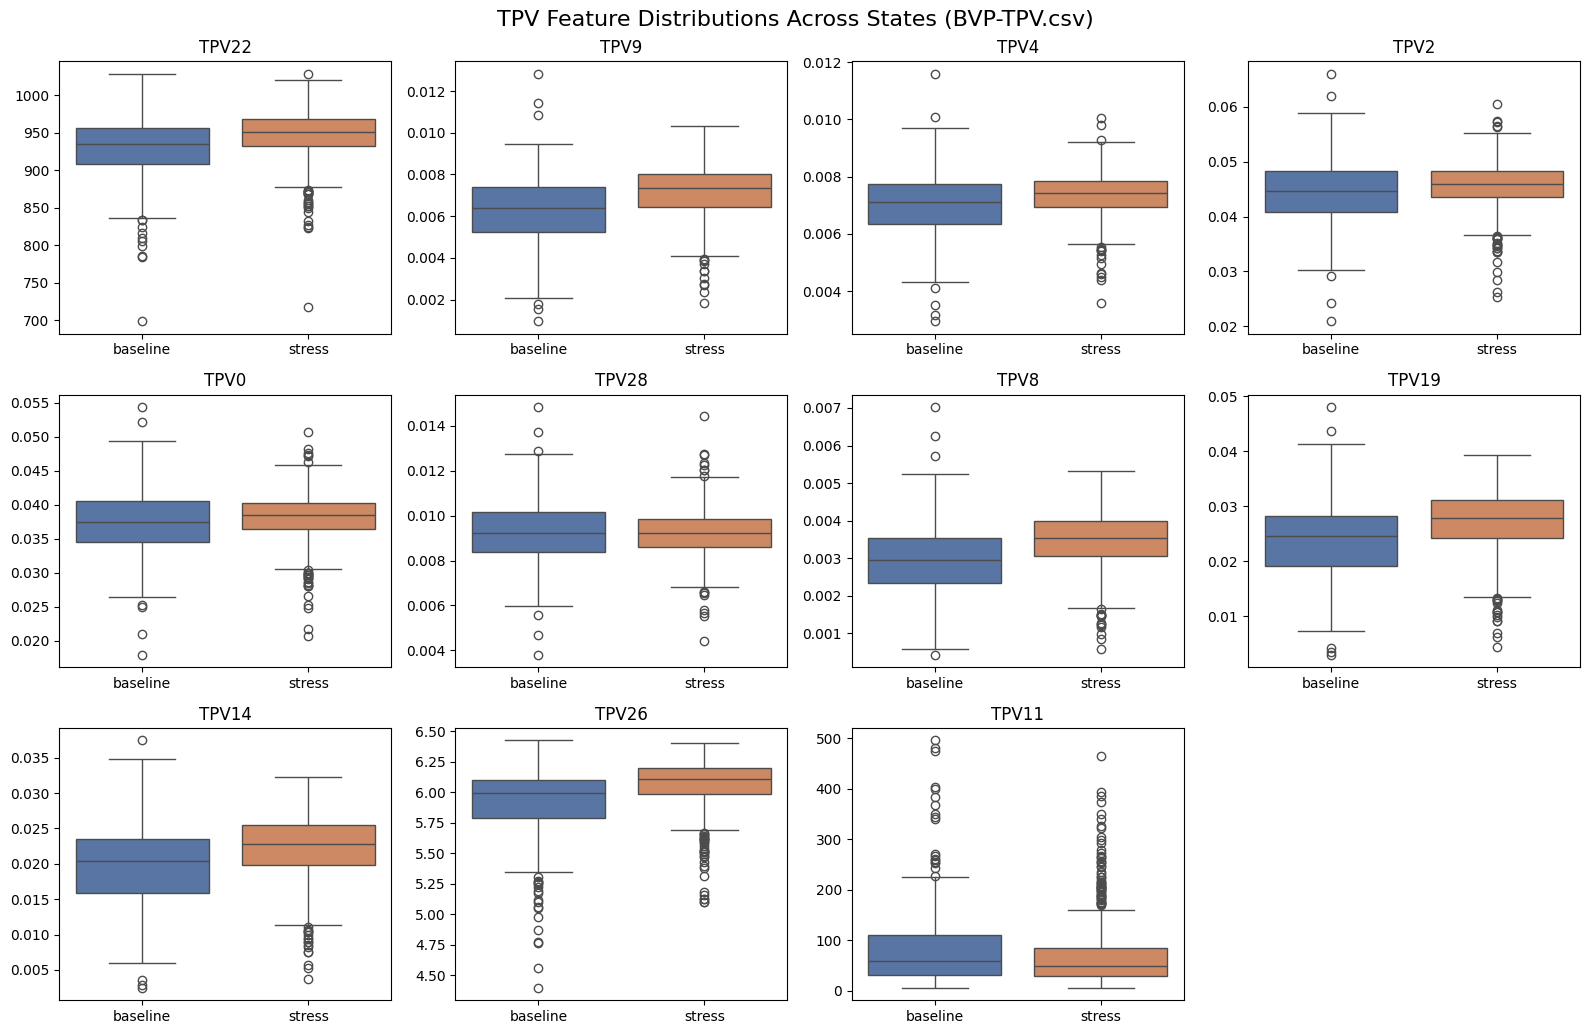


===== TPV Feature Summary =====
feature Baseline (mean±std) Stress (mean±std)         direction      anova_p
  TPV26       5.911 ± 0.297     6.069 ± 0.198 stress > baseline 2.432520e-23
   TPV8       0.003 ± 0.001     0.003 ± 0.001 stress > baseline 2.582306e-23
   TPV9       0.006 ± 0.002     0.007 ± 0.001 stress > baseline 2.132241e-21
  TPV19       0.024 ± 0.007     0.027 ± 0.006 stress > baseline 7.094100e-20
  TPV14       0.020 ± 0.006     0.022 ± 0.004 stress > baseline 5.963725e-18
  TPV22    929.909 ± 40.908  947.931 ± 33.255 stress > baseline 4.180474e-14
   TPV4       0.007 ± 0.001     0.007 ± 0.001 stress > baseline 1.202696e-09
   TPV2       0.044 ± 0.006     0.046 ± 0.004 stress > baseline 8.584940e-05
  TPV11     85.451 ± 79.970   69.622 ± 62.980 stress < baseline 4.806556e-04
   TPV0       0.037 ± 0.005     0.038 ± 0.003 stress > baseline 1.002081e-03
  TPV28       0.009 ± 0.001     0.009 ± 0.001 stress > baseline 7.953248e-01


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import f_oneway

# -------------------------
# load
# -------------------------
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/EmpaticaE4Stress/BVP_TPV/noQC_BVP.csv")

if "status_name" in df.columns:
    df["state"] = df["status_name"].replace({
        "normal": "baseline",
        "stress": "stress"
    })
else:
    df["state"] = df["label_major"].map({
        0: "baseline",
        1: "stress"
    })

# -------------------------
# TPV feature 전체 자동 선택
# -------------------------
tpv_features = [c for c in df.columns if c.startswith("TPV")]

print("Detected TPV features:")
print(tpv_features)
print(f"Total TPV features: {len(tpv_features)}")

results = []

# -------------------------
# Figure (전체 TPV boxplots)
# -------------------------
n_features = len(tpv_features)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
axes = axes.flatten()

for i, feature in enumerate(tpv_features):
    data = df[["state", feature]].dropna()

    sns.boxplot(
        x="state",
        y=feature,
        data=data,
        ax=axes[i],
        palette=["#4C72B0", "#DD8452"]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    # 2-class라서 baseline vs stress만 사용
    b = data[data.state == "baseline"][feature]
    s = data[data.state == "stress"][feature]

    # ANOVA (2그룹이어도 가능)
    anova = f_oneway(b, s)

    summary = data.groupby("state")[feature].agg(["mean", "std"])

    results.append({
        "feature": feature,
        "baseline_mean": summary.loc["baseline", "mean"] if "baseline" in summary.index else None,
        "baseline_std": summary.loc["baseline", "std"] if "baseline" in summary.index else None,
        "stress_mean": summary.loc["stress", "mean"] if "stress" in summary.index else None,
        "stress_std": summary.loc["stress", "std"] if "stress" in summary.index else None,
        "direction": "stress > baseline" if summary.loc["stress", "mean"] > summary.loc["baseline", "mean"] else "stress < baseline",
        "anova_p": anova.pvalue
    })

# 남는 subplot 제거
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("TPV Feature Distributions Across States (BVP-TPV.csv)", fontsize=16)
plt.tight_layout()
plt.show()

# -------------------------
# Table
# -------------------------
results_df = pd.DataFrame(results)

results_df["Baseline (mean±std)"] = results_df.apply(
    lambda r: f"{r['baseline_mean']:.3f} ± {r['baseline_std']:.3f}",
    axis=1
)

results_df["Stress (mean±std)"] = results_df.apply(
    lambda r: f"{r['stress_mean']:.3f} ± {r['stress_std']:.3f}",
    axis=1
)

results_df = results_df[
    ["feature", "Baseline (mean±std)", "Stress (mean±std)", "direction", "anova_p"]
].sort_values("anova_p")

print("\n===== TPV Feature Summary =====")
print(results_df.to_string(index=False))

# EDA -> TPV

In [4]:
import os
import glob
import numpy as np
import pandas as pd

from ripser import ripser
from scipy.signal import butter, filtfilt, find_peaks, welch
from scipy.stats import iqr, skew, kurtosis, entropy
from scipy.spatial.distance import pdist
from scipy.interpolate import interp1d

# =============================================================================
# CONFIG
# =============================================================================
ROOT_DIR = r"/content/drive/MyDrive/Colab Notebooks/datasets/EmpaticaE4Stress"
OUTPUT_DIR = r"/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/EmpaticaE4Stress/EDA_TPV"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EXCLUDE_SUBJECTS = {"subject_23"}

FS_EDA = 4
FS_ACC = 32

WINDOW_SEC = 60
STEP_SEC = 60

LABEL_NORMAL = 0
LABEL_STRESS = 1

STATUS_NAME_MAP = {
    LABEL_NORMAL: "normal",
    LABEL_STRESS: "stress"
}

# ---- EDA filter ----
LOWCUT = 0.05
HIGHCUT = 1.0
FILTER_ORDER = 4

# ---- Hard reject thresholds ----
FLATLINE_EPS = 1e-4
FLATLINE_MIN_SEC = 3.0
CLIPPING_RATIO_MAX = 0.15
MIN_PEAKS_PER_MIN = 2

# ---- Relaxed QC thresholds ----
VBR_MIN = 0.30
TC_MIN = 0.30
IBI_PASS_MIN = 0.30
MOTION_PERCENTILE = 80

# ---- pseudo-event extraction ----
MIN_EVENT_DISTANCE_SEC = 1.0
IBI_MIN_SEC = 0.5
IBI_MAX_SEC = 10.0

BEAT_BEFORE_SEC = 1.0
BEAT_AFTER_SEC = 3.0
BEAT_RESAMPLED_LEN = 100

# ---- Motion artifact thresholds ----
ALLOW_MISSING = False
ACC_DIFF_THRESH = 0.05
PSD_CORR_THRESH = 0.90
PSD_FMIN = 0.05
PSD_FMAX = 1.0

TPV_FEATURE_NAMES = [
    "birth_mean", "birth_std", "death_mean", "death_std",
    "lifetime_mean", "lifetime_std", "lifetime_max", "lifetime_min",
    "lifetime_median", "lifetime_iqr", "lifetime_skew", "lifetime_kurtosis",
    "birth_max", "birth_min", "birth_median", "birth_skew", "birth_kurtosis",
    "death_max", "death_min", "death_median", "death_skew", "death_kurtosis",
    "num_lifetimes", "top1_lifetime", "top2_lifetime", "lifetime_max_div_min",
    "ph_entropy", "betti_entropy", "avg_persistence_distance", "gini_index",
    "lifetime_variance", "persistent_image_energy",
]
N_FEATURES = len(TPV_FEATURE_NAMES)


# =============================================================================
# DATA LOADERS
# =============================================================================
def load_1col_signal_csv(file_path, fs):
    raw = pd.read_csv(file_path, header=None)
    data = pd.to_numeric(raw.iloc[:, 0], errors="coerce").dropna().to_numpy(dtype=np.float32)
    timestamps = np.arange(len(data), dtype=np.float32) / fs
    return {
        "data": data,
        "timestamps": timestamps,
        "fs": fs,
        "n_samples": len(data),
        "duration_sec": len(data) / fs
    }


def load_acc_csv(file_path, fs=FS_ACC):
    raw = pd.read_csv(file_path, header=None)

    if raw.shape[1] >= 3:
        acc = raw.iloc[:, :3].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)
    else:
        tmp = raw.iloc[:, 0].astype(str).str.split(",", expand=True)
        if tmp.shape[1] < 3:
            raise ValueError(f"ACC format error in {file_path}")
        acc = tmp.iloc[:, :3].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)

    mask = np.all(np.isfinite(acc), axis=1)
    acc = acc[mask]

    timestamps = np.arange(len(acc), dtype=np.float32) / fs
    return {
        "data": acc,
        "timestamps": timestamps,
        "fs": fs,
        "n_samples": len(acc),
        "duration_sec": len(acc) / fs
    }


# =============================================================================
# PROTOCOL
# =============================================================================
def build_protocol_intervals_from_total_duration(total_duration_sec: float) -> pd.DataFrame:
    fixed_sum_excluding_task4 = (
        180 + 600 + 120 + 300 + 120 + 180 + 120 + 120 + 60 + 120
    )  # = 1920 sec

    task4_duration = float(total_duration_sec) - fixed_sum_excluding_task4
    if task4_duration <= 0:
        raise ValueError(
            f"Task4 duration <= 0. total_duration={total_duration_sec:.3f}, "
            f"fixed_sum={fixed_sum_excluding_task4}"
        )

    phases = [
        ("Rest1", 180.0, 0),
        ("Task1", 600.0, 1),
        ("Rest2", 120.0, 0),
        ("Task2", 300.0, 1),
        ("Rest3", 120.0, 0),
        ("Task3", 180.0, 1),
        ("Rest4", 120.0, 0),
        ("Task4", task4_duration, 1),
        ("Rest5", 120.0, 0),
        ("Task5", 60.0, 1),
        ("Rest6", 120.0, 0),
    ]

    rows = []
    t = 0.0
    for idx, (phase_name, dur, label) in enumerate(phases):
        rows.append({
            "interval_idx": idx,
            "phase": phase_name,
            "start": t,
            "end": t + dur,
            "duration_sec": dur,
            "label": label
        })
        t += dur

    return pd.DataFrame(rows)


def build_window_table_from_intervals(intervals_df, window_sec=60, step_sec=60):
    rows = []
    for _, r in intervals_df.iterrows():
        start = float(r["start"])
        end = float(r["end"])
        phase = r["phase"]
        label = int(r["label"])

        t = start
        while t + window_sec <= end:
            rows.append({
                "phase": phase,
                "label": label,
                "window_start": t,
                "window_end": t + window_sec,
                "major_ratio": 1.0
            })
            t += step_sec

    return pd.DataFrame(rows)


# =============================================================================
# Basic utils
# =============================================================================
def fill_nan_with_median(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32).reshape(-1).copy()
    if np.isnan(x).any():
        med = np.nanmedian(x)
        if np.isnan(med):
            med = 0.0
        x = np.nan_to_num(x, nan=med, posinf=med, neginf=med)
    return x


def fill_nan_acc_with_median(acc_xyz: np.ndarray) -> np.ndarray:
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32).copy()
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3:
        return acc_xyz
    for c in range(3):
        ch = acc_xyz[:, c]
        med = np.nanmedian(ch)
        if np.isnan(med):
            med = 0.0
        ch = np.nan_to_num(ch, nan=med, posinf=med, neginf=med)
        acc_xyz[:, c] = ch
    return acc_xyz


def bandpass_filter(sig, fs=4, low=0.05, high=1.0, order=4):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    nyq = 0.5 * fs
    low_n = low / nyq
    high_n = high / nyq

    if not (0 < low_n < high_n < 1):
        raise ValueError(f"Invalid bandpass range: low={low}, high={high}, fs={fs}")

    b, a = butter(order, [low_n, high_n], btype="band")
    return filtfilt(b, a, sig).astype(np.float32)


def zscore_1d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    mu = float(np.mean(x))
    sd = float(np.std(x))
    if sd < 1e-8:
        return np.zeros_like(x, dtype=np.float32)
    return ((x - mu) / (sd + 1e-8)).astype(np.float32)


def safe_skew(x: np.ndarray) -> float:
    if len(x) > 2 and np.std(x) > 1e-12:
        v = skew(x)
        return float(v) if np.isfinite(v) else 0.0
    return 0.0


def safe_kurtosis(x: np.ndarray) -> float:
    if len(x) > 3 and np.std(x) > 1e-12:
        v = kurtosis(x)
        return float(v) if np.isfinite(v) else 0.0
    return 0.0


def clamp01(x):
    return float(np.clip(x, 0.0, 1.0))


def compute_missing_ratio(x: np.ndarray) -> float:
    x = np.asarray(x)
    return float(np.mean(~np.isfinite(x)))


# =============================================================================
# TPV extraction
# =============================================================================
def extract_tpv_features(sig_1d: np.ndarray) -> np.ndarray:
    sig = np.asarray(sig_1d, dtype=np.float32).reshape(-1)

    if len(sig) < 3:
        return np.zeros(N_FEATURES, dtype=np.float32)

    s = float(np.std(sig))
    if s < 1e-8:
        return np.zeros(N_FEATURES, dtype=np.float32)

    sig = (sig - float(np.mean(sig))) / (s + 1e-8)

    X = np.stack([sig[:-1], sig[1:]], axis=1)
    dgms = ripser(X, maxdim=1)["dgms"]
    H1 = dgms[1]

    if H1.size == 0:
        return np.zeros(N_FEATURES, dtype=np.float32)

    births = H1[:, 0]
    deaths = H1[:, 1]
    lifetimes = deaths - births

    mask = np.isfinite(births) & np.isfinite(deaths) & np.isfinite(lifetimes)
    births = births[mask]
    deaths = deaths[mask]
    lifetimes = lifetimes[mask]

    if len(lifetimes) == 0:
        return np.zeros(N_FEATURES, dtype=np.float32)

    lifetimes_sorted = np.sort(lifetimes)
    lifetime_sum = float(np.sum(lifetimes))
    lifetime_ratio = lifetimes / (lifetime_sum + 1e-8)
    ph_entropy = float(-np.sum(lifetime_ratio * np.log(lifetime_ratio + 1e-10)))

    bmin = float(np.min(births))
    bmax = float(np.max(births))
    if bmax - bmin < 1e-8:
        betti_entropy = 0.0
    else:
        hist, _ = np.histogram(births, bins=10, range=(bmin, bmax), density=True)
        betti_entropy = float(entropy(hist + 1e-10))

    avg_persistence_distance = (
        float(np.mean(pdist(lifetimes[:, None]))) if len(lifetimes) > 1 else 0.0
    )

    if np.sum(lifetimes_sorted) > 0 and len(lifetimes_sorted) > 1:
        n = len(lifetimes_sorted)
        gini = (
            2 * np.sum(np.arange(1, n + 1) * lifetimes_sorted)
        ) / (n * np.sum(lifetimes_sorted)) - (n + 1) / n
        gini_index = float(gini)
    else:
        gini_index = 0.0

    lifetime_variance = float(np.var(lifetimes))
    persistent_image_energy = float(np.sum(lifetimes ** 2))

    feats = [
        float(np.mean(births)), float(np.std(births)),
        float(np.mean(deaths)), float(np.std(deaths)),
        float(np.mean(lifetimes)), float(np.std(lifetimes)),
        float(np.max(lifetimes)), float(np.min(lifetimes)),
        float(np.median(lifetimes)), float(iqr(lifetimes)),
        safe_skew(lifetimes), safe_kurtosis(lifetimes),
        float(np.max(births)), float(np.min(births)),
        float(np.median(births)), safe_skew(births), safe_kurtosis(births),
        float(np.max(deaths)), float(np.min(deaths)),
        float(np.median(deaths)), safe_skew(deaths), safe_kurtosis(deaths),
        float(len(lifetimes)),
        float(lifetimes_sorted[-1]),
        float(lifetimes_sorted[-2]) if len(lifetimes_sorted) > 1 else 0.0,
        float(np.max(lifetimes) / (np.min(lifetimes) + 1e-8)),
        ph_entropy,
        betti_entropy,
        avg_persistence_distance,
        gini_index,
        lifetime_variance,
        persistent_image_energy,
    ]
    return np.asarray(feats, dtype=np.float32)


# =============================================================================
# QC metric helpers
# =============================================================================
def is_flatline(sig: np.ndarray, fs: int, eps: float = 1e-4, min_sec: float = 3.0) -> bool:
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    run_len = int(round(fs * min_sec))
    if len(sig) < run_len:
        return False
    ds = np.abs(np.diff(sig))
    low_change = ds < eps
    cnt = 0
    for v in low_change:
        if v:
            cnt += 1
            if cnt >= run_len - 1:
                return True
        else:
            cnt = 0
    return False


def clipping_ratio(sig: np.ndarray) -> float:
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    if len(sig) == 0:
        return 1.0
    lo = np.percentile(sig, 1)
    hi = np.percentile(sig, 99)
    if hi - lo < 1e-8:
        return 1.0
    near_lo = sig <= (lo + 0.01 * (hi - lo))
    near_hi = sig >= (hi - 0.01 * (hi - lo))
    return float(np.mean(near_lo | near_hi))


def detect_eda_peaks(sig: np.ndarray, fs: int):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    distance = max(1, int(round(MIN_EVENT_DISTANCE_SEC * fs)))
    prom = max(0.03, 0.10 * float(np.std(sig)))
    peaks, props = find_peaks(sig, distance=distance, prominence=prom)
    return peaks, props


def compute_motion_score(acc_xyz: np.ndarray) -> float:
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32)
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3 or len(acc_xyz) < 2:
        return 1.0
    mag = np.sqrt(np.sum(acc_xyz ** 2, axis=1))
    dmag = np.abs(np.diff(mag))
    score = np.median(dmag) + 0.5 * np.std(dmag)
    return float(score)


def compute_acc_diff_metrics(acc_xyz: np.ndarray):
    acc_xyz = np.asarray(acc_xyz, dtype=np.float32)
    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3 or len(acc_xyz) < 2:
        return {
            "acc_diff_mean": np.nan,
            "acc_diff_exceed_ratio": np.nan,
            "acc_diff_flag": 1
        }

    mag = np.sqrt(np.sum(acc_xyz ** 2, axis=1))
    dmag = np.abs(np.diff(mag))

    acc_diff_mean = float(np.mean(dmag)) if len(dmag) > 0 else 0.0
    acc_diff_exceed_ratio = float(np.mean(dmag > ACC_DIFF_THRESH)) if len(dmag) > 0 else 0.0
    acc_diff_flag = int(acc_diff_mean > ACC_DIFF_THRESH)

    return {
        "acc_diff_mean": acc_diff_mean,
        "acc_diff_exceed_ratio": acc_diff_exceed_ratio,
        "acc_diff_flag": acc_diff_flag
    }


def _safe_psd_1d(x: np.ndarray, fs: int, fmin: float, fmax: float):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) < 8:
        return None, None

    x = x[np.isfinite(x)]
    if len(x) < 8:
        return None, None

    if np.std(x) < 1e-8:
        return None, None

    nperseg = min(256, len(x))
    f, pxx = welch(x, fs=fs, nperseg=nperseg)

    mask = (f >= fmin) & (f <= min(fmax, fs / 2 - 1e-6))
    if np.sum(mask) < 4:
        return None, None

    return f[mask], pxx[mask]


def _corr_on_common_freq(f_ref, p_ref, f_other, p_other):
    if f_ref is None or f_other is None:
        return np.nan

    p_other_interp = np.interp(f_ref, f_other, p_other)
    a = np.log1p(p_ref)
    b = np.log1p(p_other_interp)

    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return np.nan

    r = np.corrcoef(a, b)[0, 1]
    return float(r) if np.isfinite(r) else np.nan


def compute_eda_acc_psd_corr(seg_eda_bp: np.ndarray, seg_acc_xyz: np.ndarray,
                             fs_eda: int, fs_acc: int,
                             fmin: float = PSD_FMIN, fmax: float = PSD_FMAX):
    out = {
        "psd_corr_x": np.nan,
        "psd_corr_y": np.nan,
        "psd_corr_z": np.nan,
        "psd_corr_mag": np.nan,
        "psd_corr_max": np.nan,
        "psd_corr_flag": 1
    }

    seg_eda_bp = np.asarray(seg_eda_bp, dtype=np.float32).reshape(-1)
    acc_xyz = np.asarray(seg_acc_xyz, dtype=np.float32)

    if acc_xyz.ndim != 2 or acc_xyz.shape[1] != 3:
        return out

    f_eda, p_eda = _safe_psd_1d(seg_eda_bp, fs_eda, fmin, fmax)
    if f_eda is None:
        return out

    acc_mag = np.sqrt(np.sum(acc_xyz ** 2, axis=1))

    corr_list = []
    names_and_signals = [
        ("x", acc_xyz[:, 0]),
        ("y", acc_xyz[:, 1]),
        ("z", acc_xyz[:, 2]),
        ("mag", acc_mag),
    ]

    for name, sig in names_and_signals:
        f_acc, p_acc = _safe_psd_1d(sig, fs_acc, fmin, fmax)
        r = _corr_on_common_freq(f_eda, p_eda, f_acc, p_acc)
        out[f"psd_corr_{name}"] = r
        if np.isfinite(r):
            corr_list.append(r)

    if len(corr_list) == 0:
        return out

    psd_corr_max = float(np.max(corr_list))
    out["psd_corr_max"] = psd_corr_max
    out["psd_corr_flag"] = int(psd_corr_max >= PSD_CORR_THRESH)

    return out


def extract_events(sig: np.ndarray, peaks: np.ndarray, fs: int):
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    events = []
    before = int(round(BEAT_BEFORE_SEC * fs))
    after = int(round(BEAT_AFTER_SEC * fs))
    target_x = np.linspace(0, 1, BEAT_RESAMPLED_LEN)

    for p in peaks:
        s = p - before
        e = p + after
        if s < 0 or e > len(sig):
            continue
        evt = sig[s:e].copy()
        if len(evt) < 5:
            continue
        src_x = np.linspace(0, 1, len(evt))
        f = interp1d(src_x, evt, kind="linear")
        evt_rs = f(target_x).astype(np.float32)
        events.append(evt_rs)

    if len(events) == 0:
        return np.empty((0, BEAT_RESAMPLED_LEN), dtype=np.float32)
    return np.stack(events, axis=0)


def median_template_corr(beats: np.ndarray) -> float:
    if beats.ndim != 2 or len(beats) < 2:
        return 0.0
    template = np.median(beats, axis=0)
    tc_list = []
    for b in beats:
        sb = np.std(b)
        st = np.std(template)
        if sb < 1e-8 or st < 1e-8:
            tc_list.append(0.0)
        else:
            r = np.corrcoef(b, template)[0, 1]
            tc_list.append(float(r) if np.isfinite(r) else 0.0)
    return float(np.median(tc_list)) if len(tc_list) > 0 else 0.0


def compute_interval_metrics(peaks: np.ndarray, fs: int):
    peaks = np.asarray(peaks, dtype=np.int64)
    if len(peaks) < 3:
        return {
            "n_peaks": int(len(peaks)),
            "ibi_pass_ratio": 0.0,
            "valid_beat_ratio": 0.0,
            "ibi_plausibility": 0.0,
            "ibi_mean_sec": np.nan,
        }

    ibi = np.diff(peaks) / float(fs)
    plausible = (ibi >= IBI_MIN_SEC) & (ibi <= IBI_MAX_SEC)
    ibi_pass_ratio = float(np.mean(plausible)) if len(ibi) > 0 else 0.0

    if len(ibi) >= 3:
        med_ibi = np.median(ibi)
        valid = plausible & (np.abs(ibi - med_ibi) <= 0.50 * (med_ibi + 1e-8))
        vbr = float(np.mean(valid))
    else:
        vbr = ibi_pass_ratio

    return {
        "n_peaks": int(len(peaks)),
        "ibi_pass_ratio": ibi_pass_ratio,
        "valid_beat_ratio": vbr,
        "ibi_plausibility": ibi_pass_ratio,
        "ibi_mean_sec": float(np.mean(ibi)) if len(ibi) > 0 else np.nan,
    }


def notch_foot_peak_detectability_score(beats: np.ndarray) -> float:
    if beats.ndim != 2 or len(beats) == 0:
        return 0.0

    scores = []
    for b in beats:
        foot = np.min(b[:max(5, len(b)//4)])
        peak = np.max(b)
        amp = peak - foot
        dyn = np.max(b) - np.min(b) + 1e-8
        s = amp / dyn
        scores.append(clamp01(s))

    return float(np.median(scores)) if len(scores) > 0 else 0.0


def compute_sqi_scores(vbr, tc, ibi_plausibility, motion_score, morph_score):
    motion_penalty = clamp01(motion_score)

    sqi_stress_basic = (
        0.40 * clamp01(vbr)
        + 0.30 * clamp01(tc)
        + 0.20 * clamp01(ibi_plausibility)
        - 0.10 * motion_penalty
    )

    sqi_stress_morph = (
        0.30 * clamp01(vbr)
        + 0.25 * clamp01(tc)
        + 0.20 * clamp01(ibi_plausibility)
        + 0.25 * clamp01(morph_score)
        - motion_penalty
    )

    return float(sqi_stress_basic), float(sqi_stress_morph), motion_penalty


def evaluate_window_quality(seg_eda_raw: np.ndarray, seg_acc_xyz: np.ndarray, fs_eda: int, fs_acc: int):
    out = {}

    # 컬럼명은 기존 WESAD 구조 맞추기 위해 bvp_missing_ratio 유지
    out["bvp_missing_ratio"] = compute_missing_ratio(seg_eda_raw)
    out["acc_missing_ratio"] = compute_missing_ratio(seg_acc_xyz)
    out["missing_flag"] = int(
        (out["bvp_missing_ratio"] > 0.0) or (out["acc_missing_ratio"] > 0.0)
    ) if not ALLOW_MISSING else 0

    seg_eda = fill_nan_with_median(seg_eda_raw)
    seg_acc_xyz = fill_nan_acc_with_median(seg_acc_xyz)

    seg_eda_bp = bandpass_filter(seg_eda, fs=fs_eda, low=LOWCUT, high=HIGHCUT, order=FILTER_ORDER)
    seg_eda_z = zscore_1d(seg_eda_bp)

    out["flatline_flag"] = int(is_flatline(seg_eda_bp, fs=fs_eda))
    out["clipping_ratio"] = clipping_ratio(seg_eda_bp)
    out["clipping_flag"] = int(out["clipping_ratio"] > CLIPPING_RATIO_MAX)

    peaks, props = detect_eda_peaks(seg_eda_z, fs=fs_eda)
    out["n_peaks"] = int(len(peaks))
    out["peak_sparse_flag"] = int(len(peaks) < MIN_PEAKS_PER_MIN)

    ibi_info = compute_interval_metrics(peaks, fs_eda)
    out.update(ibi_info)

    beats = extract_events(seg_eda_z, peaks, fs_eda)
    tc = median_template_corr(beats)
    morph_score = notch_foot_peak_detectability_score(beats)
    motion_score_raw = compute_motion_score(seg_acc_xyz)

    out["median_template_corr"] = float(tc)
    out["notch_foot_peak_detectability"] = float(morph_score)
    out["motion_score_raw"] = float(motion_score_raw)

    sqi_basic, sqi_morph, motion_penalty = compute_sqi_scores(
        vbr=out["valid_beat_ratio"],
        tc=tc,
        ibi_plausibility=out["ibi_plausibility"],
        motion_score=motion_score_raw,
        morph_score=morph_score
    )

    out["motion_score"] = float(motion_penalty)
    out["SQI_stress_basic"] = float(sqi_basic)
    out["SQI_stress_morph"] = float(sqi_morph)

    acc_diff_info = compute_acc_diff_metrics(seg_acc_xyz)
    out.update(acc_diff_info)

    psd_corr_info = compute_eda_acc_psd_corr(
        seg_eda_bp=seg_eda_bp,
        seg_acc_xyz=seg_acc_xyz,
        fs_eda=fs_eda,
        fs_acc=fs_acc,
        fmin=PSD_FMIN,
        fmax=PSD_FMAX
    )
    out.update(psd_corr_info)

    hard_reject = (
        (out["missing_flag"] == 1) or
        (out["flatline_flag"] == 1) or
        (out["clipping_flag"] == 1) or
        (out["peak_sparse_flag"] == 1) or
        (out["acc_diff_flag"] == 1) or
        (out["psd_corr_flag"] == 1)
    )
    out["hard_reject"] = int(hard_reject)

    return seg_eda_z, out


# =============================================================================
# Build table for one subject
# =============================================================================
def build_subject_windows_table(subject_dir: str, subject_name: str) -> pd.DataFrame:
    eda_path = os.path.join(subject_dir, "EDA.csv")
    acc_path = os.path.join(subject_dir, "ACC.csv")

    if not (os.path.exists(eda_path) and os.path.exists(acc_path)):
        return pd.DataFrame()

    eda_pack = load_1col_signal_csv(eda_path, FS_EDA)
    acc_pack = load_acc_csv(acc_path, FS_ACC)

    eda = eda_pack["data"]
    acc = acc_pack["data"]

    total_duration_sec = min(eda_pack["duration_sec"], acc_pack["duration_sec"])

    intervals_df = build_protocol_intervals_from_total_duration(total_duration_sec)
    window_df = build_window_table_from_intervals(intervals_df, WINDOW_SEC, STEP_SEC)

    We = int(WINDOW_SEC * FS_EDA)
    Wa = int(WINDOW_SEC * FS_ACC)

    rows = []
    window_counter = 0

    for _, w in window_df.iterrows():
        t0 = float(w["window_start"])
        t1 = float(w["window_end"])

        start_e = int(round(t0 * FS_EDA))
        end_e = start_e + We
        start_a = int(round(t0 * FS_ACC))
        end_a = start_a + Wa

        if end_e > len(eda) or end_a > len(acc):
            continue

        seg_eda_raw = eda[start_e:end_e]
        seg_acc_xyz = acc[start_a:end_a]

        if len(seg_eda_raw) != We or len(seg_acc_xyz) != Wa:
            continue

        seg_eda_for_tpv, qc_info = evaluate_window_quality(seg_eda_raw, seg_acc_xyz, FS_EDA, FS_ACC)
        tpv_full = extract_tpv_features(seg_eda_for_tpv)

        window_counter += 1

        row = {
            "subject": subject_name,
            "window": f"window{window_counter}",
            "window_index": window_counter,
            "status": int(w["label"]),
            "status_name": STATUS_NAME_MAP[int(w["label"])],
            "label_major": int(w["label"]),
            "phase": w["phase"],
            "t_start_sec": float(t0),
            "t_end_sec": float(t1),
            "major_ratio": float(w["major_ratio"]),
            "subject_total_duration_sec": total_duration_sec,
            "task4_duration_sec": float(intervals_df.loc[intervals_df["phase"] == "Task4", "duration_sec"].iloc[0]),
        }

        for k, v in qc_info.items():
            row[k] = v

        for idx in range(N_FEATURES):
            row[f"TPV{idx}"] = float(tpv_full[idx])

        rows.append(row)

    return pd.DataFrame(rows)


# =============================================================================
# Build all subjects
# =============================================================================
def build_all_subjects_windows_table(root_dir: str) -> pd.DataFrame:
    subject_dirs = sorted([d for d in glob.glob(os.path.join(root_dir, "subject_*")) if os.path.isdir(d)])
    all_dfs = []

    print(f"[INFO] Found {len(subject_dirs)} subject folders")

    for subject_dir in subject_dirs:
        subject_name = os.path.basename(subject_dir)

        if subject_name in EXCLUDE_SUBJECTS:
            print(f"[INFO] Skip excluded subject: {subject_name}")
            continue

        print(f"\n[INFO] Processing {subject_name} ...")
        try:
            df_sub = build_subject_windows_table(subject_dir, subject_name)
            print(f"[INFO] {subject_name}: extracted {len(df_sub)} target windows")
            if len(df_sub) > 0:
                all_dfs.append(df_sub)
        except Exception as e:
            print(f"[WARN] Failed on {subject_name}: {e}")

    if len(all_dfs) == 0:
        return pd.DataFrame()

    return pd.concat(all_dfs, axis=0, ignore_index=True)


# =============================================================================
# Personalized QC pass/fail
# =============================================================================
def apply_relaxed_personalized_qc(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    motion_thr_map = (
        df.groupby("subject")["motion_score"]
        .quantile(MOTION_PERCENTILE / 100.0)
        .to_dict()
    )

    df["motion_threshold_subject_p80"] = df["subject"].map(motion_thr_map)

    df["qc_relaxed_pass"] = (
        (df["hard_reject"] == 0) &
        (df["valid_beat_ratio"] >= VBR_MIN) &
        (df["median_template_corr"] >= TC_MIN) &
        (df["ibi_pass_ratio"] >= IBI_PASS_MIN) &
        (df["motion_score"] <= df["motion_threshold_subject_p80"])
    ).astype(int)

    return df


# =============================================================================
# Main
# =============================================================================
if __name__ == "__main__":
    df_all = build_all_subjects_windows_table(ROOT_DIR)

    print("\n[INFO] final raw shape:", df_all.shape)
    if len(df_all) == 0:
        print("[WARN] No target windows extracted.")
        raise SystemExit

    df_all = apply_relaxed_personalized_qc(df_all)

    base_cols = [
        "subject", "window", "window_index",
        "status", "status_name", "label_major", "phase",
        "t_start_sec", "t_end_sec", "major_ratio",
        "subject_total_duration_sec", "task4_duration_sec"
    ]

    qc_cols = [
        "bvp_missing_ratio", "acc_missing_ratio", "missing_flag",
        "flatline_flag", "clipping_ratio", "clipping_flag",
        "n_peaks", "peak_sparse_flag",
        "ibi_pass_ratio", "valid_beat_ratio", "ibi_plausibility", "ibi_mean_sec",
        "median_template_corr", "notch_foot_peak_detectability",
        "acc_diff_mean", "acc_diff_exceed_ratio", "acc_diff_flag",
        "psd_corr_x", "psd_corr_y", "psd_corr_z", "psd_corr_mag",
        "psd_corr_max", "psd_corr_flag",
        "motion_score_raw", "motion_score",
        "SQI_stress_basic", "SQI_stress_morph",
        "hard_reject", "motion_threshold_subject_p80", "qc_relaxed_pass"
    ]

    feat_cols = [f"TPV{i}" for i in range(N_FEATURES)]

    final_cols = base_cols + qc_cols + feat_cols
    df_all = df_all[final_cols].copy()

    csv_all = os.path.join(OUTPUT_DIR, "noQC_EDA.csv")
    df_all.to_csv(csv_all, index=False)
    print(f"[INFO] Saved no-QC CSV: {csv_all}")

    df_qc = df_all[df_all["qc_relaxed_pass"] == 1].copy()
    csv_qc = os.path.join(OUTPUT_DIR, "withQC_EDA.csv")
    df_qc.to_csv(csv_qc, index=False)
    print(f"[INFO] Saved QC CSV: {csv_qc}")

    summary = (
        df_all.groupby(["subject", "status_name"])
        .agg(
            n_total=("window", "count"),
            n_qc_pass=("qc_relaxed_pass", "sum")
        )
        .reset_index()
    )
    summary["retention_ratio"] = summary["n_qc_pass"] / summary["n_total"]

    summary_csv = os.path.join(OUTPUT_DIR, "summary_EDA.csv")
    summary.to_csv(summary_csv, index=False)
    print(f"[INFO] Saved QC retention summary: {summary_csv}")

    print("\n[INFO] Status counts (all target windows)")
    print(df_all["status_name"].value_counts())

    print("\n[INFO] Status counts (QC passed)")
    print(df_qc["status_name"].value_counts())

    print("\n[INFO] Subject x status retention summary")
    print(summary.to_string(index=False))

[INFO] Found 29 subject folders

[INFO] Processing subject_01 ...
[INFO] subject_01: extracted 41 target windows

[INFO] Processing subject_02 ...
[INFO] subject_02: extracted 39 target windows

[INFO] Processing subject_03 ...
[WARN] Failed on subject_03: Task4 duration <= 0. total_duration=1020.500, fixed_sum=1920

[INFO] Processing subject_04 ...
[WARN] Failed on subject_04: Task4 duration <= 0. total_duration=1668.250, fixed_sum=1920

[INFO] Processing subject_05 ...
[INFO] subject_05: extracted 34 target windows

[INFO] Processing subject_06 ...
[WARN] Failed on subject_06: Task4 duration <= 0. total_duration=921.750, fixed_sum=1920

[INFO] Processing subject_07 ...
[INFO] subject_07: extracted 35 target windows

[INFO] Processing subject_08 ...
[INFO] subject_08: extracted 37 target windows

[INFO] Processing subject_09 ...
[INFO] subject_09: extracted 37 target windows

[INFO] Processing subject_10 ...
[INFO] subject_10: extracted 36 target windows

[INFO] Processing subject_11 

Detected TPV features:
['TPV0', 'TPV1', 'TPV2', 'TPV3', 'TPV4', 'TPV5', 'TPV6', 'TPV7', 'TPV8', 'TPV9', 'TPV10', 'TPV11', 'TPV12', 'TPV13', 'TPV14', 'TPV15', 'TPV16', 'TPV17', 'TPV18', 'TPV19', 'TPV20', 'TPV21', 'TPV22', 'TPV23', 'TPV24', 'TPV25', 'TPV26', 'TPV27', 'TPV28', 'TPV29', 'TPV30', 'TPV31']
Total TPV features: 32


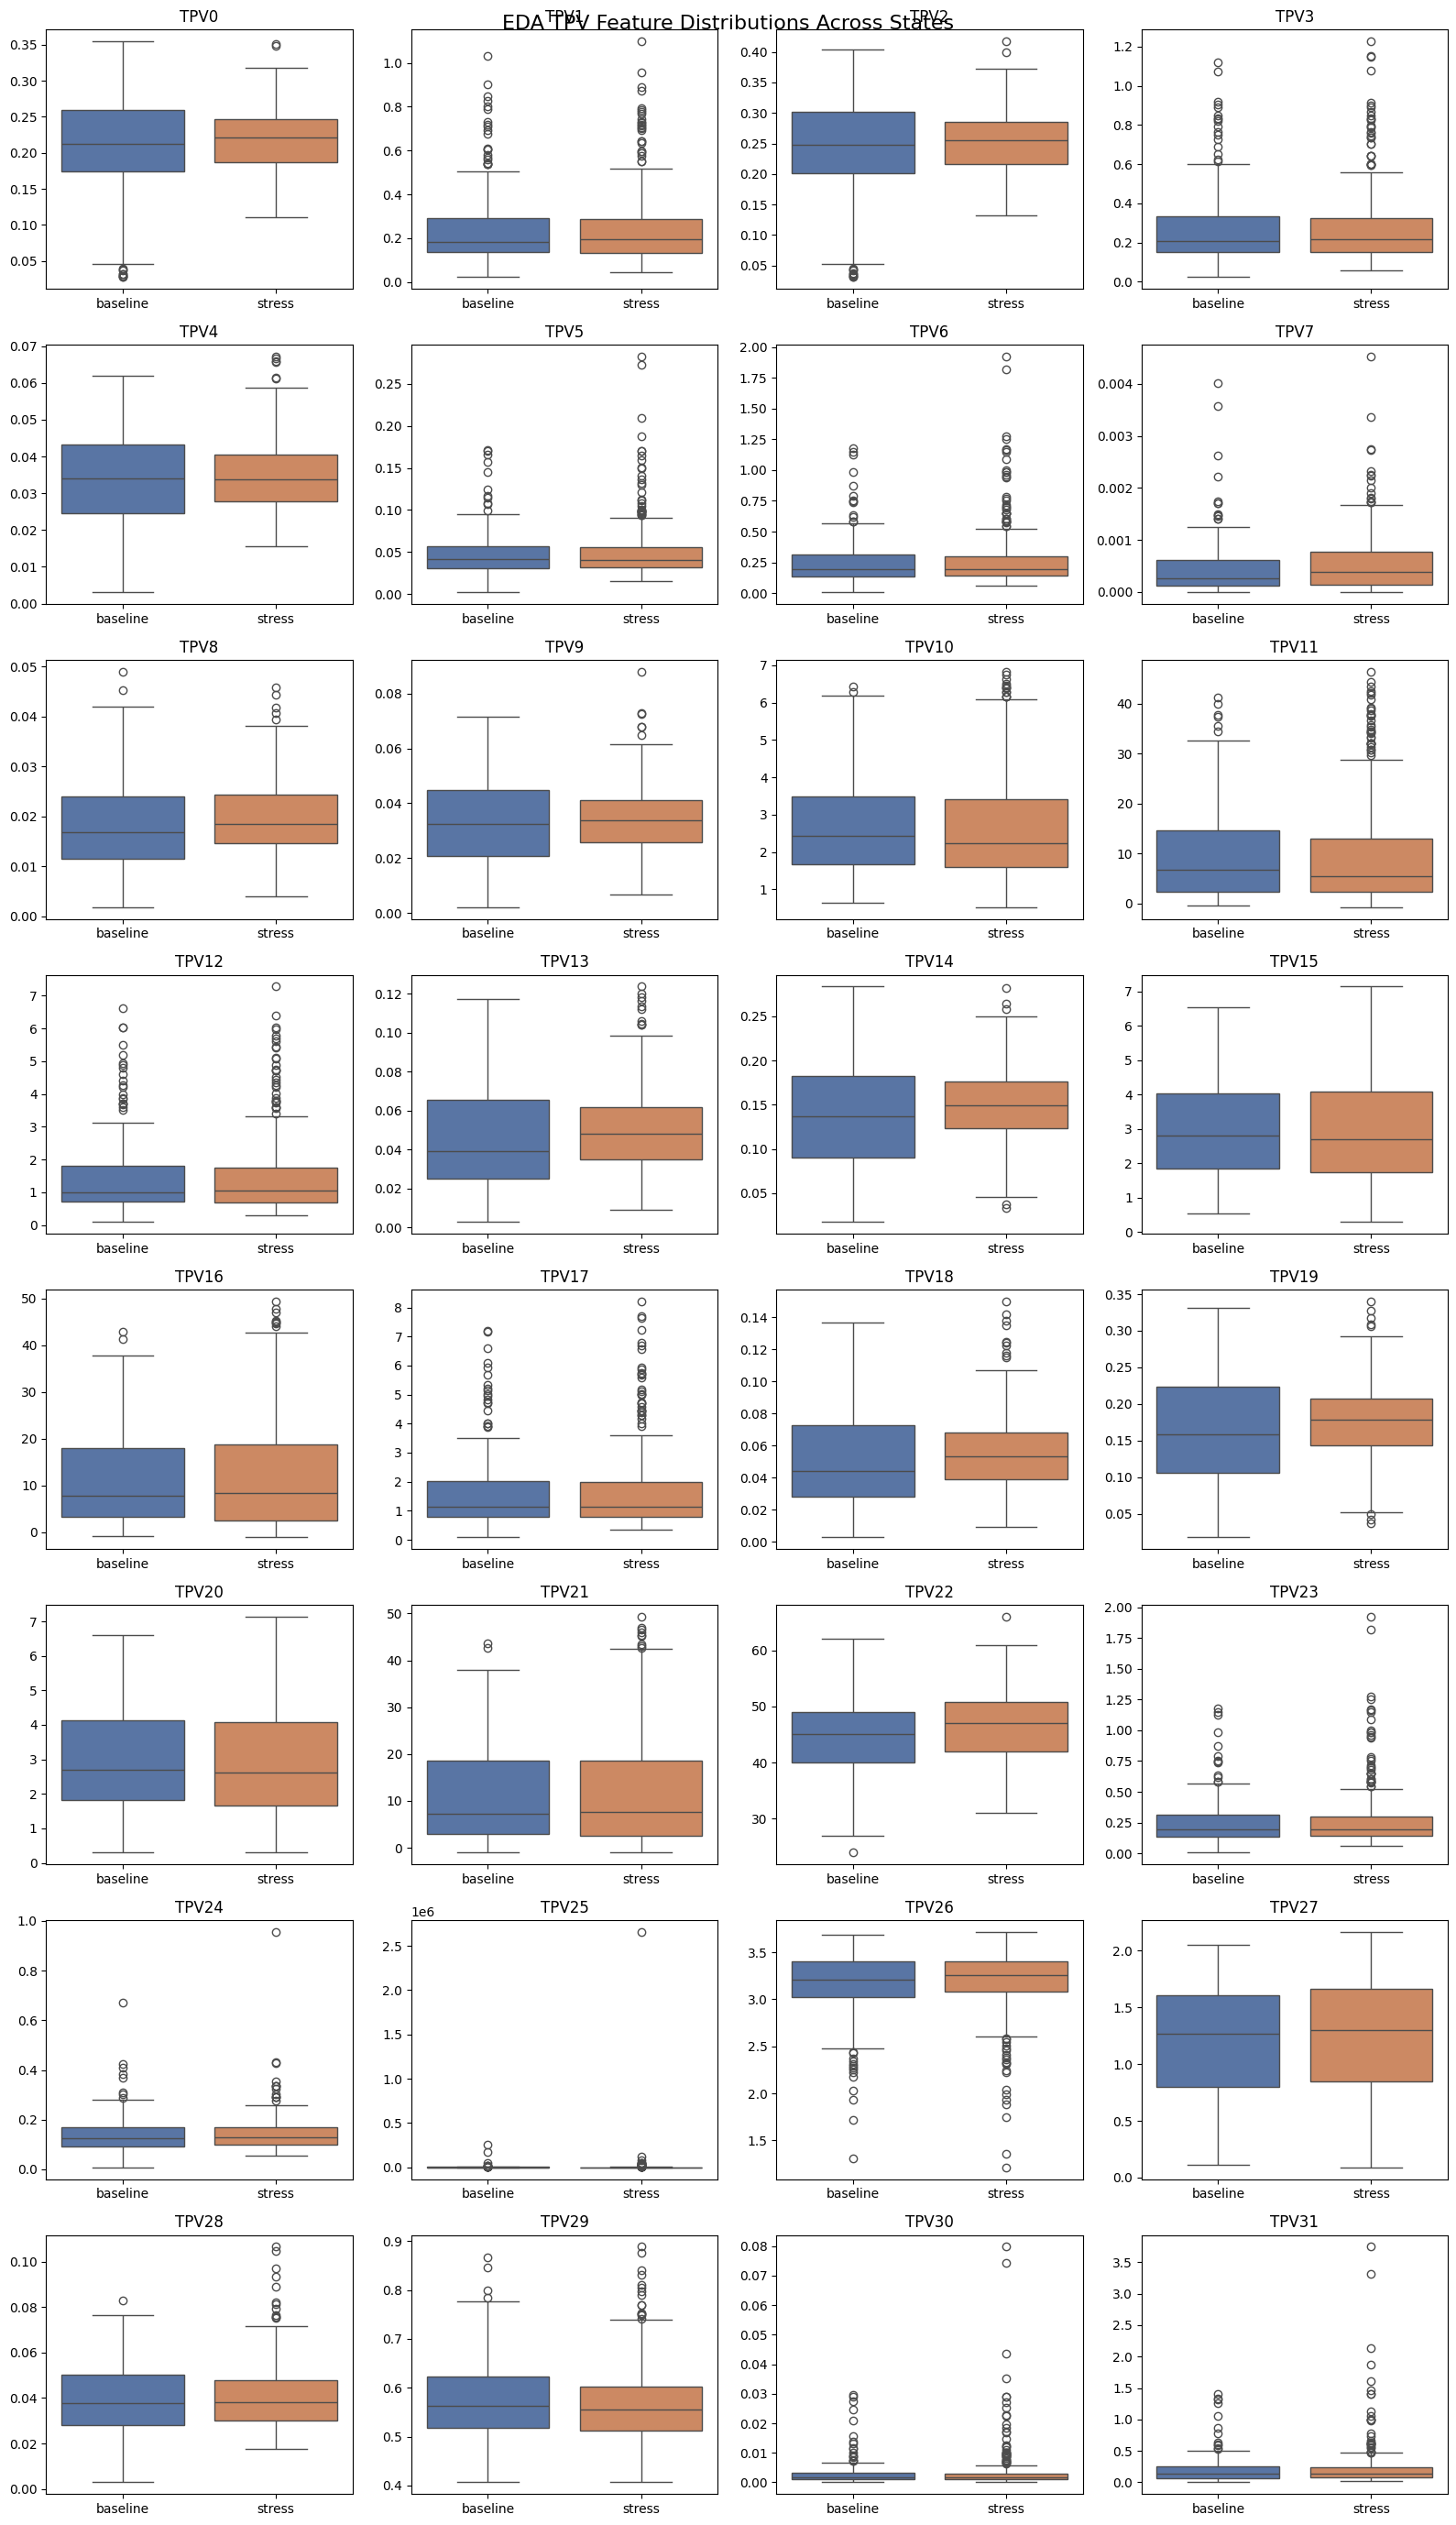


===== EDA TPV Feature Summary =====
feature  Baseline (mean±std)      Stress (mean±std)         direction  anova_p
  TPV14        0.137 ± 0.063          0.149 ± 0.041 stress > baseline 0.005867
  TPV19        0.162 ± 0.077          0.178 ± 0.051 stress > baseline 0.006825
   TPV2        0.240 ± 0.084          0.255 ± 0.050 stress > baseline 0.015137
   TPV0        0.207 ± 0.072          0.220 ± 0.042 stress > baseline 0.015795
   TPV4        0.033 ± 0.013          0.035 ± 0.010 stress > baseline 0.037042
  TPV22       45.236 ± 6.916         46.332 ± 5.983 stress > baseline 0.060653
  TPV26        3.136 ± 0.392          3.197 ± 0.345 stress > baseline 0.069905
  TPV13        0.046 ± 0.029          0.050 ± 0.022 stress > baseline 0.079812
   TPV8        0.018 ± 0.010          0.020 ± 0.007 stress > baseline 0.082780
  TPV18        0.051 ± 0.032          0.055 ± 0.025 stress > baseline 0.105573
   TPV7        0.000 ± 0.001          0.001 ± 0.001 stress > baseline 0.107764
  TPV29        

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import f_oneway

# -------------------------
# load
# -------------------------
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/EmpaticaE4Stress/EDA_TPV/noQC_EDA.csv")

if "status_name" in df.columns:
    df["state"] = df["status_name"].replace({
        "normal": "baseline",
        "stress": "stress"
    })
else:
    df["state"] = df["label_major"].map({
        0: "baseline",
        1: "stress"
    })

# -------------------------
# TPV feature 전체 자동 선택
# -------------------------
tpv_features = [c for c in df.columns if c.startswith("TPV")]

print("Detected TPV features:")
print(tpv_features)
print(f"Total TPV features: {len(tpv_features)}")

results = []

# -------------------------
# Figure (전체 TPV boxplots)
# -------------------------
n_features = len(tpv_features)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
axes = axes.flatten()

for i, feature in enumerate(tpv_features):
    data = df[["state", feature]].dropna()

    sns.boxplot(
        x="state",
        y=feature,
        data=data,
        ax=axes[i],
        palette=["#4C72B0", "#DD8452"]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    b = data[data.state == "baseline"][feature]
    s = data[data.state == "stress"][feature]

    anova = f_oneway(b, s)
    summary = data.groupby("state")[feature].agg(["mean", "std"])

    results.append({
        "feature": feature,
        "baseline_mean": summary.loc["baseline", "mean"] if "baseline" in summary.index else None,
        "baseline_std": summary.loc["baseline", "std"] if "baseline" in summary.index else None,
        "stress_mean": summary.loc["stress", "mean"] if "stress" in summary.index else None,
        "stress_std": summary.loc["stress", "std"] if "stress" in summary.index else None,
        "direction": "stress > baseline" if summary.loc["stress", "mean"] > summary.loc["baseline", "mean"] else "stress < baseline",
        "anova_p": anova.pvalue
    })

# 남는 subplot 제거
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("EDA TPV Feature Distributions Across States", fontsize=16)
plt.tight_layout()
plt.show()

# -------------------------
# Table
# -------------------------
results_df = pd.DataFrame(results)

results_df["Baseline (mean±std)"] = results_df.apply(
    lambda r: f"{r['baseline_mean']:.3f} ± {r['baseline_std']:.3f}",
    axis=1
)

results_df["Stress (mean±std)"] = results_df.apply(
    lambda r: f"{r['stress_mean']:.3f} ± {r['stress_std']:.3f}",
    axis=1
)

results_df = results_df[
    ["feature", "Baseline (mean±std)", "Stress (mean±std)", "direction", "anova_p"]
].sort_values("anova_p")

print("\n===== EDA TPV Feature Summary =====")
print(results_df.to_string(index=False))

# IBI -> HRV

In [ ]:
import os
import glob
import numpy as np
import pandas as pd

from scipy.signal import welch
from scipy.interpolate import interp1d

# =============================================================================
# CONFIG
# =============================================================================
ROOT_DIR = r"/content/drive/MyDrive/Colab Notebooks/datasets/EmpaticaE4Stress"
OUTPUT_DIR = r"/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/EmpaticaE4Stress/HRV"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EXCLUDE_SUBJECTS = {"subject_23"}   # 예: {"subject_17"}

FS_BVP = 64.0
WINDOW_SEC = 60
STEP_SEC = 60
MAJORITY_RATIO_MIN = 0.95   # 현재 interval 내부 window만 자르므로 사실상 1.0

# HRV / IBI QC
FS_IBI_INTERP = 4.0
LF_LOW = 0.04
LF_HIGH = 0.15
HF_LOW = 0.15
HF_HIGH = 0.40

IBI_MIN_SEC = 0.30
IBI_MAX_SEC = 1.50
IBI_DIFF_RATIO_MAX = 0.30

# =============================================================================
# LOADERS
# =============================================================================
def load_bvp_csv(file_path, fs=FS_BVP):
    """
    BVP.csv:
    - 1 column raw signal
    - no header
    - no start timestamp
    """
    raw = pd.read_csv(file_path, header=None)
    bvp = pd.to_numeric(raw.iloc[:, 0], errors="coerce").dropna().to_numpy(dtype=np.float64)

    timestamps = np.arange(len(bvp), dtype=np.float64) / fs
    return pd.DataFrame({
        "timestamp": timestamps,
        "bvp": bvp
    })


def load_ibi_csv(file_path):
    """
    IBI.csv:
    - 2 columns: offset_sec, ibi_sec
    - no header
    - offsets are relative to recording start
    """
    raw = pd.read_csv(file_path, header=None)

    if raw.shape[1] < 2:
        raise ValueError(f"IBI format error: expected 2 columns, got {raw.shape[1]} in {file_path}")

    ibi_df = raw.iloc[:, :2].copy()
    ibi_df.columns = ["offset_sec", "ibi"]
    ibi_df = ibi_df.dropna()

    ibi_df["offset_sec"] = pd.to_numeric(ibi_df["offset_sec"], errors="coerce")
    ibi_df["ibi"] = pd.to_numeric(ibi_df["ibi"], errors="coerce")
    ibi_df = ibi_df.dropna().reset_index(drop=True)

    ibi_df["timestamp"] = ibi_df["offset_sec"].astype(float)
    return ibi_df[["timestamp", "offset_sec", "ibi"]]


# =============================================================================
# PROTOCOL (Task4 auto-estimation)
# =============================================================================
def build_protocol_intervals_from_total_duration(total_duration_sec):
    """
    Protocol from the paper:
      Rest1  = 180 sec
      Task1  = 600 sec
      Rest2  = 120 sec
      Task2  = 300 sec
      Rest3  = 120 sec
      Task3  = 180 sec
      Rest4  = 120 sec
      Task4  = variable
      Rest5  = 120 sec
      Task5  =  60 sec
      Rest6  = 120 sec

    label:
      normal = 0 (all rest)
      stress = 1 (all tasks)
    """
    fixed_sum_excluding_task4 = (
        180 + 600 + 120 + 300 + 120 + 180 + 120 + 120 + 60 + 120
    )  # = 1920 sec

    task4_duration = float(total_duration_sec) - fixed_sum_excluding_task4

    if task4_duration <= 0:
        raise ValueError(
            f"Task4 duration <= 0. total_duration={total_duration_sec:.3f}, "
            f"fixed_sum={fixed_sum_excluding_task4}"
        )

    phase_info = [
        ("Rest1", 180.0, 0),
        ("Task1", 600.0, 1),
        ("Rest2", 120.0, 0),
        ("Task2", 300.0, 1),
        ("Rest3", 120.0, 0),
        ("Task3", 180.0, 1),
        ("Rest4", 120.0, 0),
        ("Task4", task4_duration, 1),
        ("Rest5", 120.0, 0),
        ("Task5", 60.0, 1),
        ("Rest6", 120.0, 0),
    ]

    rows = []
    t = 0.0
    for idx, (phase_name, dur, label) in enumerate(phase_info):
        rows.append({
            "interval_idx": idx,
            "phase": phase_name,
            "start": t,
            "end": t + dur,
            "duration_sec": dur,
            "label": label
        })
        t += dur

    return pd.DataFrame(rows)


def build_window_table_from_intervals(intervals_df, window_sec=60, step_sec=60, majority_ratio_min=0.95):
    """
    interval 내부에서만 window를 자르므로 major_ratio는 1.0
    """
    rows = []

    for _, r in intervals_df.iterrows():
        start = float(r["start"])
        end = float(r["end"])
        phase = r["phase"]
        label = int(r["label"])

        t = start
        while t + window_sec <= end:
            rows.append({
                "phase": phase,
                "label": label,
                "window_start": t,
                "window_end": t + window_sec,
                "major_ratio": 1.0
            })
            t += step_sec

    return pd.DataFrame(rows)


# =============================================================================
# HRV HELPERS
# =============================================================================
def safe_div(a, b):
    return float(a / b) if abs(b) > 1e-12 else np.nan


def build_filtered_ibi_series(ibi_times_abs, ibi_values):
    ibi_times_abs = np.asarray(ibi_times_abs, dtype=np.float64).reshape(-1)
    ibi_values = np.asarray(ibi_values, dtype=np.float64).reshape(-1)

    if len(ibi_times_abs) < 2 or len(ibi_values) < 2:
        return None

    # 1) physiological plausibility
    plausible = (ibi_values >= IBI_MIN_SEC) & (ibi_values <= IBI_MAX_SEC)
    ibi_values = ibi_values[plausible]
    ibi_times_abs = ibi_times_abs[plausible]

    if len(ibi_values) < 2:
        return None

    # 2) remove abrupt outliers around median
    med_ibi = float(np.median(ibi_values))
    stable = np.abs(ibi_values - med_ibi) <= (IBI_DIFF_RATIO_MAX * (med_ibi + 1e-8))

    ibi_values = ibi_values[stable]
    ibi_times_abs = ibi_times_abs[stable]

    if len(ibi_values) < 2:
        return None

    return {
        "ibi_times_abs": ibi_times_abs,
        "ibi": ibi_values,
        "ibi_median_sec": med_ibi
    }


def interpolate_ibi(ibi_times_abs, ibi, fs_interp=FS_IBI_INTERP):
    ibi_times_abs = np.asarray(ibi_times_abs, dtype=np.float64).reshape(-1)
    ibi = np.asarray(ibi, dtype=np.float64).reshape(-1)

    if len(ibi_times_abs) < 2 or len(ibi) < 2:
        return None
    if ibi_times_abs[-1] <= ibi_times_abs[0]:
        return None

    t_uniform = np.arange(ibi_times_abs[0], ibi_times_abs[-1], 1.0 / fs_interp)
    if len(t_uniform) < 4:
        return None

    try:
        f_interp = interp1d(
            ibi_times_abs,
            ibi,
            kind="linear",
            bounds_error=False,
            fill_value="extrapolate",
            assume_sorted=True
        )
        ibi_uniform = f_interp(t_uniform)
    except Exception:
        return None

    ibi_uniform = np.asarray(ibi_uniform, dtype=np.float64)
    if np.any(~np.isfinite(ibi_uniform)):
        return None

    return {"t_uniform": t_uniform, "ibi_uniform": ibi_uniform}


def compute_time_domain_hrv(ibi):
    ibi = np.asarray(ibi, dtype=np.float64).reshape(-1)

    if len(ibi) < 2:
        return {
            "RMSSD": np.nan,
            "SDNN": np.nan,
            "ibi_mean_sec": np.nan,
            "ibi_std_sec": np.nan,
        }

    diff_ibi = np.diff(ibi)
    rmssd = np.sqrt(np.mean(diff_ibi ** 2)) if len(diff_ibi) > 0 else np.nan
    sdnn = np.std(ibi, ddof=0)

    return {
        "RMSSD": float(rmssd) if np.isfinite(rmssd) else np.nan,
        "SDNN": float(sdnn) if np.isfinite(sdnn) else np.nan,
        "ibi_mean_sec": float(np.mean(ibi)) if np.isfinite(np.mean(ibi)) else np.nan,
        "ibi_std_sec": float(np.std(ibi, ddof=0)) if np.isfinite(np.std(ibi, ddof=0)) else np.nan,
    }


def compute_freq_domain_hrv(ibi_uniform, fs_interp=FS_IBI_INTERP):
    ibi_uniform = np.asarray(ibi_uniform, dtype=np.float64).reshape(-1)
    if len(ibi_uniform) < 8:
        return {"LF": np.nan, "HF": np.nan, "LF_HF": np.nan}

    nperseg = min(256, len(ibi_uniform))
    f, pxx = welch(ibi_uniform, fs=fs_interp, nperseg=nperseg)

    lf_mask = (f >= LF_LOW) & (f < LF_HIGH)
    hf_mask = (f >= HF_LOW) & (f < HF_HIGH)

    lf = np.trapz(pxx[lf_mask], f[lf_mask]) if np.any(lf_mask) else np.nan
    hf = np.trapz(pxx[hf_mask], f[hf_mask]) if np.any(hf_mask) else np.nan
    lf_hf = safe_div(lf, hf) if np.isfinite(lf) and np.isfinite(hf) else np.nan

    return {
        "LF": float(lf) if np.isfinite(lf) else np.nan,
        "HF": float(hf) if np.isfinite(hf) else np.nan,
        "LF_HF": float(lf_hf) if np.isfinite(lf_hf) else np.nan,
    }


def extract_hrv_features_from_ibi_segment(seg_ibi_df):
    ibi_times_abs = seg_ibi_df["timestamp"].values
    ibi_values = seg_ibi_df["ibi"].values

    row = {
        "n_ibi": int(len(ibi_values)),
        "ibi_pass_ratio": np.nan,
        "valid_ibi_count": 0,
        "ibi_mean_sec": np.nan,
        "ibi_std_sec": np.nan,
        "RMSSD": np.nan,
        "SDNN": np.nan,
        "LF": np.nan,
        "HF": np.nan,
        "LF_HF": np.nan,
    }

    if len(ibi_values) < 2:
        return row

    plausible = (ibi_values >= IBI_MIN_SEC) & (ibi_values <= IBI_MAX_SEC)
    row["ibi_pass_ratio"] = float(np.mean(plausible)) if len(ibi_values) > 0 else np.nan

    pack = build_filtered_ibi_series(ibi_times_abs, ibi_values)
    if pack is None:
        return row

    ibi = pack["ibi"]
    ibi_times_abs = pack["ibi_times_abs"]
    row["valid_ibi_count"] = int(len(ibi))

    td = compute_time_domain_hrv(ibi)
    row.update(td)

    interp_pack = interpolate_ibi(ibi_times_abs, ibi, fs_interp=FS_IBI_INTERP)
    if interp_pack is None:
        return row

    fd = compute_freq_domain_hrv(interp_pack["ibi_uniform"], fs_interp=FS_IBI_INTERP)
    row.update(fd)
    return row


# =============================================================================
# MAIN EXTRACTION
# =============================================================================
def extract_subject_ibi_hrv(subject_dir):
    subject_id = os.path.basename(subject_dir)
    if subject_id in EXCLUDE_SUBJECTS:
        return pd.DataFrame()

    ibi_path = os.path.join(subject_dir, "IBI.csv")
    bvp_path = os.path.join(subject_dir, "BVP.csv")

    if not (os.path.exists(ibi_path) and os.path.exists(bvp_path)):
        print(f"[WARN] {subject_id}: missing BVP or IBI")
        return pd.DataFrame()

    # total duration from BVP
    bvp_df = load_bvp_csv(bvp_path, fs=FS_BVP)
    total_duration_sec = float(bvp_df["timestamp"].iloc[-1]) if len(bvp_df) > 0 else 0.0

    # protocol intervals with Task4 auto-estimated
    intervals_df = build_protocol_intervals_from_total_duration(total_duration_sec)
    window_df = build_window_table_from_intervals(
        intervals_df,
        window_sec=WINDOW_SEC,
        step_sec=STEP_SEC,
        majority_ratio_min=MAJORITY_RATIO_MIN
    )

    ibi_df = load_ibi_csv(ibi_path)

    rows = []
    window_counter = 0

    for _, w in window_df.iterrows():
        t0 = float(w["window_start"])
        t1 = float(w["window_end"])

        seg_ibi_df = ibi_df[(ibi_df["timestamp"] >= t0) & (ibi_df["timestamp"] < t1)].copy()
        hrv_info = extract_hrv_features_from_ibi_segment(seg_ibi_df)

        window_counter += 1
        row = {
            "subject": subject_id,
            "window": f"window{window_counter}",
            "window_index": window_counter,
            "window_sec": WINDOW_SEC,
            "status": int(w["label"]),
            "status_name": "stress" if int(w["label"]) == 1 else "normal",
            "phase": w["phase"],
            "t_start_sec": t0,
            "t_end_sec": t1,
            "major_ratio": float(w["major_ratio"]),
            "subject_total_duration_sec": total_duration_sec,
            "task4_duration_sec": float(
                intervals_df.loc[intervals_df["phase"] == "Task4", "duration_sec"].iloc[0]
            )
        }
        row.update(hrv_info)
        rows.append(row)

    return pd.DataFrame(rows)


def main():
    subject_dirs = sorted(
        [d for d in glob.glob(os.path.join(ROOT_DIR, "subject_*")) if os.path.isdir(d)]
    )

    print(f"[INFO] Found {len(subject_dirs)} subject folders")

    all_dfs = []

    for subject_dir in subject_dirs:
        sid = os.path.basename(subject_dir)
        if sid in EXCLUDE_SUBJECTS:
            print(f"[INFO] Skip excluded subject: {sid}")
            continue

        print(f"[INFO] Processing {sid} ...")
        try:
            df_sub = extract_subject_ibi_hrv(subject_dir)
            print(f"[INFO] {sid}: extracted {len(df_sub)} windows")
            if len(df_sub) > 0:
                all_dfs.append(df_sub)
        except Exception as e:
            print(f"[WARN] Failed on {sid}: {e}")

    if len(all_dfs) == 0:
        print("[WARN] No windows extracted.")
        return

    df_all = pd.concat(all_dfs, axis=0, ignore_index=True)

    base_cols = [
        "subject", "window", "window_index", "window_sec",
        "status", "status_name", "phase",
        "t_start_sec", "t_end_sec", "major_ratio",
        "subject_total_duration_sec", "task4_duration_sec"
    ]
    hrv_cols = [
        "n_ibi",
        "ibi_pass_ratio",
        "valid_ibi_count",
        "ibi_mean_sec",
        "ibi_std_sec",
        "RMSSD",
        "SDNN",
        "LF",
        "HF",
        "LF_HF",
    ]

    df_all = df_all[base_cols + hrv_cols].copy()

    csv_path = os.path.join(OUTPUT_DIR, "EmpaticaE4Stress_IBI_HRV_1min.csv")
    df_all.to_csv(csv_path, index=False)

    summary = (
        df_all.groupby(["subject", "status_name"])
        .agg(
            n_windows=("window", "count"),
            n_valid_rmssd=("RMSSD", lambda x: int(np.sum(np.isfinite(x)))),
            n_valid_lf_hf=("LF_HF", lambda x: int(np.sum(np.isfinite(x)))),
            mean_n_ibi=("n_ibi", "mean"),
            mean_valid_ibi=("valid_ibi_count", "mean"),
        )
        .reset_index()
    )
    summary_csv = os.path.join(OUTPUT_DIR, "EmpaticaE4Stress_IBI_HRV_1min_summary.csv")
    summary.to_csv(summary_csv, index=False)

    task4_summary = (
        df_all.groupby("subject")
        .agg(
            total_duration_sec=("subject_total_duration_sec", "first"),
            task4_duration_sec=("task4_duration_sec", "first")
        )
        .reset_index()
    )
    task4_csv = os.path.join(OUTPUT_DIR, "EmpaticaE4Stress_Task4_duration_summary.csv")
    task4_summary.to_csv(task4_csv, index=False)

    print(f"[INFO] Saved: {csv_path}")
    print(f"[INFO] Saved: {summary_csv}")
    print(f"[INFO] Saved: {task4_csv}")
    print("\n[INFO] Status counts")
    print(df_all["status_name"].value_counts())


if __name__ == "__main__":
    main()

[INFO] Found 29 subject folders
[INFO] Processing subject_01 ...


/tmp/ipykernel_8906/1574087690.py:274: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(pxx[lf_mask], f[lf_mask]) if np.any(lf_mask) else np.nan
/tmp/ipykernel_8906/1574087690.py:275: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(pxx[hf_mask], f[hf_mask]) if np.any(hf_mask) else np.nan


[INFO] subject_01: extracted 41 windows
[INFO] Processing subject_02 ...


/tmp/ipykernel_8906/1574087690.py:274: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(pxx[lf_mask], f[lf_mask]) if np.any(lf_mask) else np.nan
/tmp/ipykernel_8906/1574087690.py:275: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(pxx[hf_mask], f[hf_mask]) if np.any(hf_mask) else np.nan


[INFO] subject_02: extracted 39 windows
[INFO] Processing subject_03 ...


...

/tmp/ipykernel_8906/1574087690.py:274: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(pxx[lf_mask], f[lf_mask]) if np.any(lf_mask) else np.nan
/tmp/ipykernel_8906/1574087690.py:275: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(pxx[hf_mask], f[hf_mask]) if np.any(hf_mask) else np.nan


[INFO] subject_27: extracted 35 windows
[INFO] Processing subject_28 ...


/tmp/ipykernel_8906/1574087690.py:274: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(pxx[lf_mask], f[lf_mask]) if np.any(lf_mask) else np.nan
/tmp/ipykernel_8906/1574087690.py:275: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(pxx[hf_mask], f[hf_mask]) if np.any(hf_mask) else np.nan


[INFO] subject_28: extracted 41 windows
[INFO] Processing subject_29 ...
[INFO] subject_29: extracted 38 windows
[INFO] Saved: /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/EmpaticaE4Stress/HRV/EmpaticaE4Stress_IBI_HRV_1min.csv
[INFO] Saved: /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/EmpaticaE4Stress/HRV/EmpaticaE4Stress_IBI_HRV_1min_summary.csv
[INFO] Saved: /content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/EmpaticaE4Stress/HRV/EmpaticaE4Stress_Task4_duration_summary.csv

[INFO] Status counts
status_name
stress    671
normal    364
Name: count, dtype: int64


/tmp/ipykernel_8906/1574087690.py:274: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf = np.trapz(pxx[lf_mask], f[lf_mask]) if np.any(lf_mask) else np.nan
/tmp/ipykernel_8906/1574087690.py:275: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf = np.trapz(pxx[hf_mask], f[hf_mask]) if np.any(hf_mask) else np.nan


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/EmpaticaE4Stress/HRV/EmpaticaE4Stress_IBI_HRV_1min.csv")
print(df.head())
print(df["status_name"].value_counts())
print(df.groupby("subject")["task4_duration_sec"].first().describe())

      subject   window  window_index  window_sec  status status_name  phase  \
0  subject_01  window1             1          60       0      normal  Rest1   
1  subject_01  window2             2          60       0      normal  Rest1   
2  subject_01  window3             3          60       0      normal  Rest1   
3  subject_01  window4             4          60       1      stress  Task1   
4  subject_01  window5             5          60       1      stress  Task1   

   t_start_sec  t_end_sec  major_ratio  ...  n_ibi  ibi_pass_ratio  \
0          0.0       60.0          1.0  ...     11             1.0   
1         60.0      120.0          1.0  ...     16             1.0   
2        120.0      180.0          1.0  ...     53             1.0   
3        180.0      240.0          1.0  ...      5             1.0   
4        240.0      300.0          1.0  ...      0             NaN   

   valid_ibi_count  ibi_mean_sec  ibi_std_sec     RMSSD      SDNN  \
0               11      0.828125   

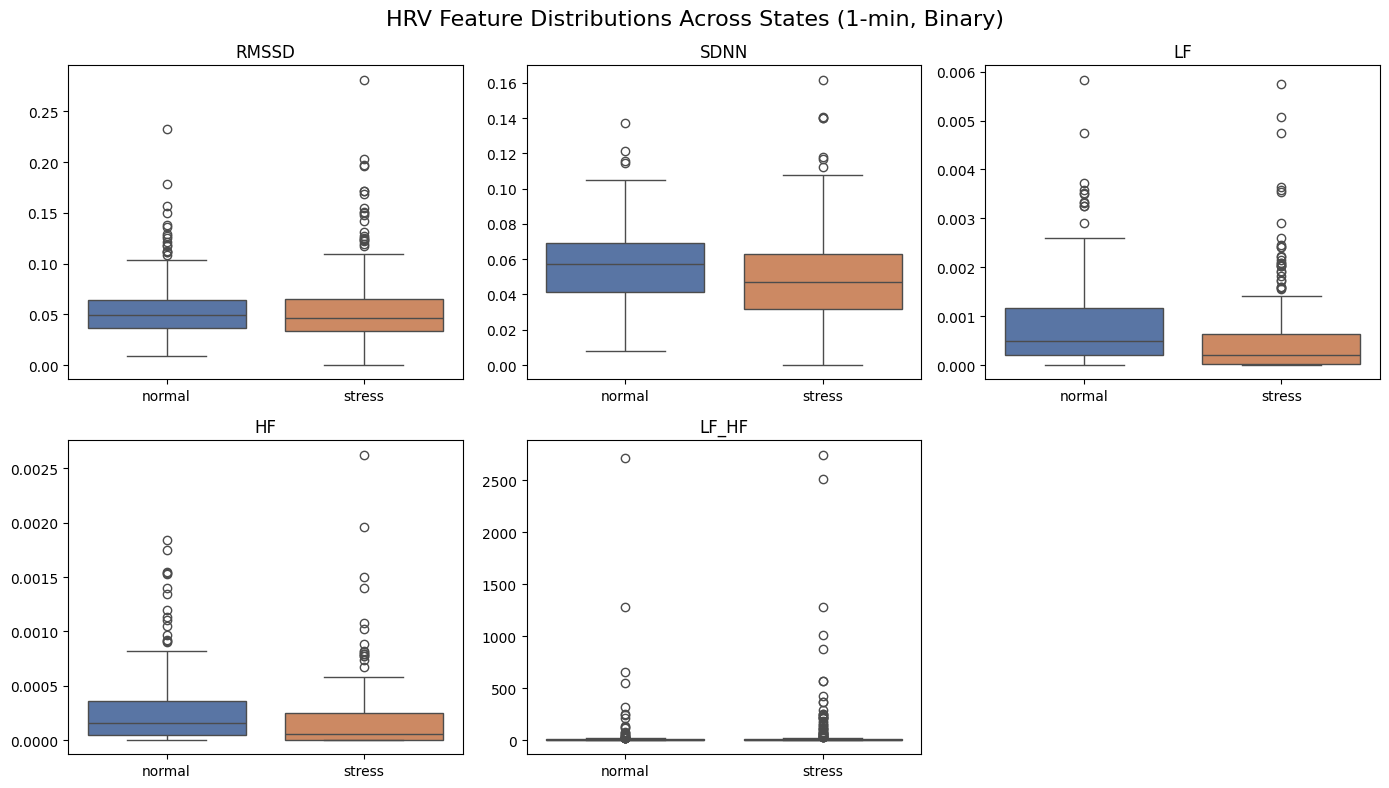


===== HRV Binary Feature Summary =====
  feature       Normal (mean±std)       Stress (mean±std)   anova_p
0   RMSSD     0.055288 ± 0.027946     0.054927 ± 0.034405  0.886846
1    SDNN     0.056520 ± 0.021111     0.049148 ± 0.024505  0.000071
2      LF     0.000805 ± 0.000897     0.000523 ± 0.000848  0.000262
3      HF     0.000267 ± 0.000325     0.000169 ± 0.000290  0.000163
4   LF_HF  31.976353 ± 197.299502  60.195332 ± 264.340524  0.171828


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

# load
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BM/TPV-stress/EmpaticaE4Stress/HRV/EmpaticaE4Stress_IBI_HRV_1min.csv")

# 현재 데이터셋은 binary
df["state"] = df["status_name"].map({
    "normal": "normal",
    "stress": "stress"
})

# HRV features
hrv_features = ["RMSSD", "SDNN", "LF", "HF", "LF_HF"]

results = []

# -------------------------
# Figure
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(hrv_features):
    data = df[["state", feature]].dropna()

    sns.boxplot(
        x="state",
        y=feature,
        data=data,
        ax=axes[i],
         palette=["#4C72B0", "#DD8452"]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    n = data[data.state == "normal"][feature]
    s = data[data.state == "stress"][feature]

    anova = f_oneway(n, s)

    summary = data.groupby("state")[feature].agg(["mean", "std"])

    results.append({
        "feature": feature,
        "normal_mean": summary.loc["normal", "mean"],
        "normal_std": summary.loc["normal", "std"],
        "stress_mean": summary.loc["stress", "mean"],
        "stress_std": summary.loc["stress", "std"],
        "anova_p": anova.pvalue
    })

fig.delaxes(axes[-1])

plt.suptitle("HRV Feature Distributions Across States (1-min, Binary)", fontsize=16)
plt.tight_layout()
plt.show()

# -------------------------
# Table
# -------------------------
results_df = pd.DataFrame(results)

results_df["Normal (mean±std)"] = results_df.apply(
    lambda r: f"{r['normal_mean']:.6f} ± {r['normal_std']:.6f}", axis=1)

results_df["Stress (mean±std)"] = results_df.apply(
    lambda r: f"{r['stress_mean']:.6f} ± {r['stress_std']:.6f}", axis=1)

results_df = results_df[[
    "feature",
    "Normal (mean±std)",
    "Stress (mean±std)",
    "anova_p"
]]

print("\n===== HRV Binary Feature Summary =====")
print(results_df)